# Детская депривация в Казахстане, 2021–2024: факторы и ассоциации

**Данные:** формы D002 / D002-КазРус (депривация, материальное положение, продовольственная
безопасность), D006 (жилищные условия), D008 (состав домохозяйства). Панель домохозяйств
2021–2024 гг., поквартальные наблюдения.

**Основная гипотеза.** Уровень детской депривации связан с регионом проживания, типом
населённого пункта (город/село), материальным положением, продовольственной безопасностью
и жилищными условиями домохозяйства.

*(Формулировка скорректирована по итогам аудита данных — см. Milestone 2: поле `Mes_rojd`
в документации подписано как «место рождения», но по коду поля и по структуре формы D008
(`месяц рождения`) фактически является месяцем рождения. Собственно места рождения ребёнка
в данных нет, поэтому гипотеза сформулирована через регион/тип поселения **текущего**
проживания, а не место рождения.)*

**Дополнительная гипотеза.** Уровень депривации детей различается в зависимости от региона,
типа населённого пункта, материального положения и жилищных условий (описательные различия
между группами).

**Использованные формы:** D002/D002-КазРус, D006, D008. Форма D004 (доходы, расходы,
алименты) в переданных данных **отсутствует как микроданные** — предоставлены только Excel-
описания её структуры, но не сами файлы наблюдений; единственный доступный денежный
показатель — агрегат `TOTAL_EXPENDITURE`.

**Методологическая схема:** аудит данных → сопоставление переменных → гармонизация →
объединение форм → аналитическая выборка → показатели → описательная статистика →
визуализация → статистические тесты → регрессия → robustness → интерпретация → выводы.

Этот ноутбук закрывает **CHECKPOINT 1** (Milestones 1–5): аудит, сопоставление переменных,
гармонизация, объединение, аналитическая выборка. Регрессионный анализ и содержательные
выводы по гипотезе на этом этапе **не выполняются**.

> **Технический комментарий по ресурсам.** Каждый годовой файл содержит ~167–171 тыс. строк
> и 510 столбцов (~0.6–0.7 ГБ в памяти pandas). Чтобы ноутбук стабильно выполнялся в средах
> с ограниченной памятью, данные **не держатся одновременно в памяти за все 4 года** —
> каждая ячейка читает нужные годы по очереди (при необходимости — только нужные столбцы
> через `usecols`) и освобождает память (`del df; gc.collect()`) перед переходом к
> следующему году.


In [2]:
import gc
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

# --- Пути ---------------------------------------------------------------
CANDIDATE_DATA_DIRS = ["/content/drive/MyDrive/Datathon2026/synthetic_microdata_2021-2024_20260921/D00X/data", "data", "."]
DATA_DIR = next((Path(p) for p in CANDIDATE_DATA_DIRS if Path(p).exists() and
                  any(Path(p).glob("master_wide_*.csv"))), Path("data"))
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS = [2021, 2022, 2023, 2024]

def year_path(y):
    return DATA_DIR / f"master_wide_{y}.csv"

def load_csv(y, usecols=None):
    return pd.read_csv(year_path(y), usecols=usecols, low_memory=False)

print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/MyDrive/Datathon2026/synthetic_microdata_2021-2024_20260921/D00X/data


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Загрузка данных

Единый источник за каждый год — файл `D00X_master_wide_<year>.csv`, уже объединяющий D002 (subject + ocenka), D006 и D008 на уровне человек×квартал. На этом шаге читаем только заголовки и размерность (без удержания данных в памяти).

In [4]:
summary_rows = []
ALL_COLUMNS = None
for y in YEARS:
    header = pd.read_csv(year_path(y), nrows=0).columns.tolist()
    n_rows = sum(1 for _ in open(year_path(y), encoding="utf-8", errors="replace")) - 1
    summary_rows.append({"year": y, "form": "D00X_master_wide (D002+D006+D008)",
                          "rows": n_rows, "columns": len(header)})
    if y == 2021:
        ALL_COLUMNS = header

dataset_summary = pd.DataFrame(summary_rows)
dataset_summary


,year,form,rows,columns
0,2021,D00X_master_wide (D002+D006+D008),167472,510
1,2022,D00X_master_wide (D002+D006+D008),170724,510
2,2023,D00X_master_wide (D002+D006+D008),170756,510
3,2024,D00X_master_wide (D002+D006+D008),167284,510


## 3. MILESTONE 1 — Аудит данных

### 3.1 Структура столбцов по форме-источнику

Каждый столбец объединённого файла имеет префикс `d002_subject__`, `d002_ocenka__`,
`d006__` или `d008__` (кроме служебных идентификаторов без префикса). Проверяем, что
структура столбцов идентична во всех 4 годах (сравнение заголовков, без чтения данных).

In [5]:
def col_group(c):
    for pref in ("d002_subject__", "d002_ocenka__", "d006__", "d008__"):
        if c.startswith(pref):
            return pref.rstrip("_")
    return "id/service"

headers = {y: pd.read_csv(year_path(y), nrows=0).columns.tolist() for y in YEARS}

group_counts = pd.DataFrame({
    y: pd.Series([col_group(c) for c in headers[y]]).value_counts()
    for y in YEARS
}).fillna(0).astype(int)
group_counts


,2021,2022,2023,2024
d006,244,244,244,244
d002_ocenka,116,116,116,116
d002_subject,108,108,108,108
d008,30,30,30,30
id/service,12,12,12,12


In [6]:
identical = {y: headers[y] == headers[2021] for y in YEARS}
print("Идентичность набора и порядка столбцов относительно 2021:", identical)


Идентичность набора и порядка столбцов относительно 2021: {2021: True, 2022: True, 2023: True, 2024: True}


**Вывод:** набор столбцов (510) идентичен во всех 4 годах — это облегчает
объединение, но **не гарантирует сопоставимость содержания** (см. Milestone 2): часть
столбцов физически присутствует, но фактически не заполнялась в отдельные годы, потому
что соответствующего вопроса в тот год в анкете не было.

### 3.2 Единица наблюдения и идентификаторы

In [7]:
id_summary_rows = []
for y in YEARS:
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "NOMP", "KVARTAL", "TE"])
    n = len(df)
    n_hh = df["HOUSEHOLD_ID"].nunique()
    dup_person_quarter = df.duplicated(subset=["HOUSEHOLD_ID", "NOMP", "KVARTAL"]).sum()
    id_summary_rows.append({
        "year": y, "rows": n, "households": n_hh,
        "rows_per_hh": round(n / n_hh, 2),
        "quarters": sorted(df["KVARTAL"].dropna().unique().tolist()),
        "dup_(hh,person,quarter)": dup_person_quarter,
        "regions_TE": df["TE"].nunique(),
    })
    del df; gc.collect()

id_summary = pd.DataFrame(id_summary_rows)
id_summary


,year,rows,households,rows_per_hh,quarters,"dup_(hh,person,quarter)",regions_TE
0,2021,167472,12000,13.96,"[1, 2, 3, 4]",0,17
1,2022,170724,12000,14.23,"[1, 2, 3, 4]",0,20
2,2023,170756,12000,14.23,"[1, 2, 3, 4]",0,20
3,2024,167284,12000,13.94,"[1, 2, 3, 4]",0,20


**Единица наблюдения:** строка = **человек × квартал** внутри домохозяйства
(ключ `HOUSEHOLD_ID` + `NOMP` (номер лица) + `KVARTAL`, дубликатов по этому ключу нет).
Домохозяйство отслеживается как панель на протяжении 4 кварталов (12 000 домохозяйств
во всех годах). Данные `D002` (депривация/материальное положение/продбезопасность)
заполняются, по-видимому, **один раз в год на респондента домохозяйства** и растиражированы
на все квартальные строки — это надо учитывать, чтобы не дублировать наблюдения при агрегации.

Идентификаторы: `HOUSEHOLD_ID` — домохозяйство, `NOMP` — номер лица в домохозяйстве
(связывает с D008), `TE` — код территории (региона), `K` — тип поселения (город/село),
`KVARTAL` — квартал. Отдельного идентификатора ребёнка нет; в блоке депривации детей
(D002_ocenka, часть 4) дети внутри домохозяйства нумеруются 1–7, но не имеют сквозного ID.

**Важно:** число регионов (`TE`) — **17 в 2021 году против 20 в 2022–2024** — это не
артефакт данных, а следствие административно-территориальной реформы РК 2022 года
(выделение новых областей). См. Milestone 2 — переменная региона требует отдельного
рассмотрения при межгодовом сравнении.

### 3.3 Веса выборки

In [8]:
weight_like = [c for c in headers[2021] if any(k in c.upper() for k in
                ["VES", "WEIGHT", "WGT", "STRATA", "PSU", "CLUSTER"])]
print("Столбцы, похожие на веса/страты/PSU:", weight_like if weight_like else "НЕ НАЙДЕНО")


Столбцы, похожие на веса/страты/PSU: НЕ НАЙДЕНО


**Вывод: переменных весов, страт или PSU в предоставленных данных нет.** Это
ограничение, которое необходимо явно указать в финальном отчёте (Milestone 17/24):
все оценки далее будут невзвешенными, доверительные интервалы не будут учитывать
сложный дизайн выборки.

### 3.4 Пропуски по группам столбцов (компактно)

In [9]:
def missing_by_group_for_year(y):
    df = load_csv(y)
    rows = []
    for pref, label in [("d002_subject__", "d002_subject"), ("d002_ocenka__", "d002_ocenka"),
                         ("d006__", "d006"), ("d008__", "d008")]:
        cols = [c for c in df.columns if c.startswith(pref)]
        miss_rate = df[cols].isna().mean().mean()
        rows.append({"group": label, "avg_missing_share": round(miss_rate, 3)})
    del df; gc.collect()
    return pd.DataFrame(rows).assign(year=y)

missing_summary = pd.concat([missing_by_group_for_year(y) for y in YEARS], ignore_index=True) \
    .pivot(index="group", columns="year", values="avg_missing_share")
missing_summary


year,2021,2022,2023,2024
group,,,,
d002_ocenka,0.922,0.919,0.905,0.905
d002_subject,0.876,0.889,0.867,0.865
d006,0.677,0.679,0.684,0.677
d008,0.615,0.549,0.576,0.476


In [10]:
# Точечная проверка ключевых полей, критичных для гипотезы
key_fields = {
    "d008__GOD_ROJD (год рождения)": "d008__GOD_ROJD",
    "d002_ocenka__KVINT (квинтиль дохода)": "d002_ocenka__KVINT",
    "d002_ocenka__GR40 (есть дети до 18)": "d002_ocenka__GR40",
    "d002_ocenka__GR44_1 (норма: одежда для ребёнка)": "d002_ocenka__GR44_1",
    "d002_ocenka__GR45_1 (депривация: одежда для ребёнка)": "d002_ocenka__GR45_1",
    "TOTAL_EXPENDITURE": "TOTAL_EXPENDITURE",
}
rows = []
for y in YEARS:
    df = load_csv(y, usecols=list(key_fields.values()))
    row = {"year": y}
    for label, col in key_fields.items():
        row[label] = round(df[col].notna().mean(), 3)
    rows.append(row)
    del df; gc.collect()
pd.DataFrame(rows).set_index("year").T


year,2021,2022,2023,2024
d008__GOD_ROJD (год рождения),0.000,1.000,1.000,1.000
d002_ocenka__KVINT (квинтиль дохода),0.000,0.000,0.280,0.000
d002_ocenka__GR40 (есть дети до 18),0.000,0.000,0.280,0.285
d002_ocenka__GR44_1 (норма: одежда для ребёнка),0.000,0.000,0.143,0.147
d002_ocenka__GR45_1 (депривация: одежда для ребёнка),0.000,0.000,0.142,0.146
TOTAL_EXPENDITURE,0.985,0.988,0.987,0.987


**Ключевые находки аудита:**

1. `d008__GOD_ROJD` (год рождения члена домохозяйства) **полностью отсутствует в 2021 году**
   (0% заполнения) и полностью заполнен в 2022–2024. Без года рождения по всем членам
   домохозяйства в 2021 году нельзя напрямую посчитать число/возраст детей на уровне
   домохозяйства — придётся использовать косвенные признаки (см. Milestone 5).
2. `d002_ocenka__GR40` («есть ли в ДХ дети до 18 лет») и весь блок детской депривации
   (`GR41`–`GR46`, включая 14+14 пунктов норм/депривации) **заполнены только в 2023–2024**;
   в 2021–2022 — 0%. Это подтверждается и структурой анкеты (см. Milestone 2): раздел
   «4 часть» появился в форме только начиная с 2023 отчётного года.
3. `d002_ocenka__KVINT` (квинтиль по доходу/благосостоянию) заполнен в 2023 (~28%
   строк-наблюдений за год) и **полностью пуст в 2024** — вероятно, технический
   пропуск в выгрузке за 2024 год, а не изменение методологии. Нужно зафиксировать как
   проблему качества данных.
4. Микроданные D004 (доходы, расходы, алименты) в файле отсутствуют; есть только один
   агрегат `TOTAL_EXPENDITURE`, доступный во всех 4 годах (~97–99% заполнения).


## 4. MILESTONE 2 — Сопоставление переменных (variable crosswalk)

Формы-структуры (`Структура_файлов.xls` — 2021; `Структура_файлов2022.xls` — 2022;
`Структура_файлов_D002_2023/2024.xls`) и текст самих бланков (`D_002_форма.pdf` — 2021;
`Д002-_казрус.pdf` — 2022–2024, приказ от 10.08.2022 №13) были прочитаны постранично
(OCR-текст, вложенный в PDF) и сопоставлены с кодами полей.

**Главный результат: D002 (2021) и D002-КазРус (2022–2024) — это разные анкеты по
структуре, а не переименованные версии одной и той же.** Совпадение имён столбцов в
выгрузке (`GR1`, `GR2`, ...) не означает совпадения содержания вопроса.

In [11]:
variable_crosswalk = pd.DataFrame([
    dict(concept="Регион (TE)", y2021="17 кодов территории", y2022="20 кодов (после реформы АТД РК 2022 г.)",
         y2023="20 кодов", y2024="20 кодов",
         comparable="Частично", transformation="Свести к общему укрупнённому классификатору областей до реформы, либо анализировать 2021 отдельно",
         notes="Реформа 2022 г. добавила новые области (выделены из существующих) — коды не биективны"),
    dict(concept="Тип поселения (K, город/село)", y2021="1/2", y2022="1/2", y2023="1/2", y2024="1/2",
         comparable="Да", transformation="—", notes="Кодировка стабильна во всех годах"),
    dict(concept="Материальное положение домохозяйства",
         y2021="EU-SILC-подобный индекс лишений (11-12 бинарных пунктов: аренда/ЖКХ/кредит, мебель, "
               "белковая пища, непредвиденные расходы, отпуск, встречи с друзьями, похороны без долгов, "
               "обувь/одежда, свободные траты, досуг)",
         y2022="Самооценка уровня достатка по 6-балльной шкале (GR21) + причины низкого уровня (GR22, 14 пунктов)",
         y2023="То же, что 2022", y2024="То же, что 2022",
         comparable="Нет", transformation="Не гармонизировать напрямую; использовать раздельно как разные конструкты",
         notes="Разные измерительные инструменты (объективный индекс лишений vs. субъективная лестница). "
               "Прямое склеивание в одну переменную 'material position' недопустимо"),
    dict(concept="Продовольственная безопасность (FIES-подобные пункты)",
         y2021="4 пункта (ели меньше нормы; еда кончалась; голодали; не ели весь день)",
         y2022="8 пунктов (полная шкала FIES: беспокойство; здоровая пища; мало видов пищи; пропуск приёма "
               "пищи; ели меньше; еда кончалась; голодали; не ели весь день)",
         y2023="8 пунктов (как 2022)", y2024="8 пунктов (как 2022)",
         comparable="Частично", transformation="Для 2021↔2022-24 сравнивать только по 4 общим пунктам; "
                     "полный 8-пунктовый FIES-индекс — только 2022-2024",
         notes="2021 — сокращённый набор вопросов; 2022+ — полная шкала FIES"),
    dict(concept="Депривация детей (наличие детей, нормы и лишения по 14 пунктам)",
         y2021="Раздела нет в форме", y2022="Раздела нет в форме",
         y2023="Есть (часть 4: GR40 флаг, GR41-GR43 по ребёнку, GR44/GR45 — по 14 пунктов норм/лишений на ДХ, GR46)",
         y2024="Есть (идентично 2023)",
         comparable="Нет (для 2021-2022 отсутствует)", transformation="Не гармонизировать; анализ депривации детей "
                     "ограничен 2023-2024",
         notes="Подтверждено и по структуре Excel, и по тексту бланка, и эмпирически (0% заполнения в 2021-2022, "
               "~28% строк-наблюдений в 2023-2024)"),
    dict(concept="Квинтиль дохода/благосостояния (KVINT)", y2021="Нет поля", y2022="Нет поля",
         y2023="Заполнено (~28%)", y2024="Присутствует в файле, но 0% заполнения",
         comparable="Проблема качества данных", transformation="Уточнить у поставщика данных; для 2024 требуется альтернативный источник квинтиля",
         notes="Похоже на технический пропуск выгрузки 2024 г., а не методологическое изменение"),
    dict(concept="Место/месяц рождения (Mes_rojd)",
         y2021="В структуре D002 подписано как 'место рождения', но код поля и структура D008 указывают на 'месяц рождения'",
         y2022="—", y2023="—", y2024="—",
         comparable="Не применимо", transformation="Не использовать как место рождения",
         notes="Данных о месте рождения ребёнка в предоставленных файлах НЕТ. Это и стало причиной "
               "переформулировки гипотезы (см. раздел 0)"),
    dict(concept="Жилищные условия (D006: площадь, комнаты, благоустройство)",
         y2021="Стабильная структура (TIP_J, OB_PL, J_PL, KOL_K, U1-U42, ...)",
         y2022="Идентична", y2023="Идентична", y2024="Идентична",
         comparable="Да", transformation="—",
         notes="Форма D006 не менялась в 2021-2024 (нет отдельных годовых версий структуры)"),
    dict(concept="Состав домохозяйства (D008: пол, родство, статус занятости)",
         y2021="Стабильная структура, НО год рождения (GOD_ROJD) не заполнен",
         y2022="Заполнено", y2023="Заполнено", y2024="Заполнено",
         comparable="Частично (2021 — без возраста по всем членам)", transformation="Для 2021 использовать альтернативные "
                     "признаки наличия детей (см. Milestone 5)",
         notes="Единственный явный разрыв качества данных внутри стабильной структуры"),
    dict(concept="Доходы / расходы / алименты (D004)",
         y2021="Микроданные не предоставлены", y2022="—", y2023="—", y2024="—",
         comparable="Недоступно", transformation="—",
         notes="Предоставлены только Excel-описания структуры D004 (kv_vopr*.xls), самих файлов наблюдений нет. "
               "Единственный доступный денежный показатель — агрегат TOTAL_EXPENDITURE"),
])
variable_crosswalk


,concept,y2021,y2022,y2023,y2024,comparable,transformation,notes
0,Регион (TE),17 кодов территории,20 кодов (после реформы АТД РК 2022 г.),20 кодов,20 кодов,Частично,Свести к общему укрупнённому классификатору об...,Реформа 2022 г. добавила новые области (выделе...
1,"Тип поселения (K, город/село)",1/2,1/2,1/2,1/2,Да,—,Кодировка стабильна во всех годах
2,Материальное положение домохозяйства,EU-SILC-подобный индекс лишений (11-12 бинарны...,Самооценка уровня достатка по 6-балльной шкале...,"То же, что 2022","То же, что 2022",Нет,Не гармонизировать напрямую; использовать разд...,Разные измерительные инструменты (объективный ...
3,Продовольственная безопасность (FIES-подобные ...,4 пункта (ели меньше нормы; еда кончалась; гол...,8 пунктов (полная шкала FIES: беспокойство; зд...,8 пунктов (как 2022),8 пунктов (как 2022),Частично,Для 2021↔2022-24 сравнивать только по 4 общим ...,2021 — сокращённый набор вопросов; 2022+ — пол...
4,"Депривация детей (наличие детей, нормы и лишен...",Раздела нет в форме,Раздела нет в форме,"Есть (часть 4: GR40 флаг, GR41-GR43 по ребёнку...",Есть (идентично 2023),Нет (для 2021-2022 отсутствует),Не гармонизировать; анализ депривации детей ог...,"Подтверждено и по структуре Excel, и по тексту..."
5,Квинтиль дохода/благосостояния (KVINT),Нет поля,Нет поля,Заполнено (~28%),"Присутствует в файле, но 0% заполнения",Проблема качества данных,Уточнить у поставщика данных; для 2024 требует...,Похоже на технический пропуск выгрузки 2024 г....
6,Место/месяц рождения (Mes_rojd),В структуре D002 подписано как 'место рождения...,—,—,—,Не применимо,Не использовать как место рождения,Данных о месте рождения ребёнка в предоставлен...
7,"Жилищные условия (D006: площадь, комнаты, благ...","Стабильная структура (TIP_J, OB_PL, J_PL, KOL_...",Идентична,Идентична,Идентична,Да,—,Форма D006 не менялась в 2021-2024 (нет отдель...
8,"Состав домохозяйства (D008: пол, родство, стат...","Стабильная структура, НО год рождения (GOD_ROJ...",Заполнено,Заполнено,Заполнено,Частично (2021 — без возраста по всем членам),Для 2021 использовать альтернативные признаки ...,Единственный явный разрыв качества данных внут...
9,Доходы / расходы / алименты (D004),Микроданные не предоставлены,—,—,—,Недоступно,—,Предоставлены только Excel-описания структуры ...


In [12]:
comparable_variables = ["Тип поселения (K)", "Жилищные условия (D006)", "Состав домохозяйства (D008, кроме возраста в 2021)"]
transformable_variables = ["Регион (TE, до/после реформы 2022 г.)",
                            "Продовольственная безопасность (только по 4 общим пунктам 2021↔2022-24)"]
non_comparable_variables = ["Материальное положение (разные инструменты 2021 vs 2022-2024)",
                             "Депривация детей (нет данных 2021-2022)",
                             "Доходы/расходы/алименты D004 (микроданные недоступны)"]
print("Сопоставимо:", comparable_variables)
print("Требует преобразования:", transformable_variables)
print("Несопоставимо / недоступно:", non_comparable_variables)


Сопоставимо: ['Тип поселения (K)', 'Жилищные условия (D006)', 'Состав домохозяйства (D008, кроме возраста в 2021)']
Требует преобразования: ['Регион (TE, до/после реформы 2022 г.)', 'Продовольственная безопасность (только по 4 общим пунктам 2021↔2022-24)']
Несопоставимо / недоступно: ['Материальное положение (разные инструменты 2021 vs 2022-2024)', 'Депривация детей (нет данных 2021-2022)', 'Доходы/расходы/алименты D004 (микроданные недоступны)']


## 5. MILESTONE 3 — Гармонизация

Вводим единые имена для переменных, признанных сопоставимыми (Milestone 2). Переменные,
не прошедшие проверку сопоставимости, **не гармонизируются** — они остаются
специфичными для своего периода и явно помечаются годом происхождения.

In [13]:
HARMONIZE_COLS = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", "TE", "K", "d008__KOL_CHL",
                  "d006__OB_PL", "d006__J_PL", "d006__KOL_K", "d006__TIP_J", "TOTAL_EXPENDITURE"]

def harmonize(y):
    df = load_csv(y, usecols=HARMONIZE_COLS)
    h = pd.DataFrame(index=df.index)
    h["year"] = y
    h["household_id"] = df["HOUSEHOLD_ID"]
    h["person_id"] = df["NOMP"]
    h["quarter"] = df["KVARTAL"]
    h["region_code"] = df["TE"]
    h["settlement_type"] = df["K"].map({1: "city", 2: "rural"})
    h["household_size"] = df["d008__KOL_CHL"]
    h["total_area_m2"] = df["d006__OB_PL"]
    h["living_area_m2"] = df["d006__J_PL"]
    h["rooms"] = df["d006__KOL_K"]
    h["dwelling_type"] = df["d006__TIP_J"]
    h["total_expenditure"] = df["TOTAL_EXPENDITURE"]
    del df; gc.collect()
    return h

harmonized = {y: harmonize(y) for y in YEARS}
harmonized[2024].head(3)


,year,household_id,person_id,quarter,region_code,settlement_type,household_size,total_area_m2,living_area_m2,rooms,dwelling_type,total_expenditure
0,2024,1,1,1,43,city,2,67.0,42.0,3.0,4.0,432536.0
1,2024,1,1,2,43,city,2,67.0,42.0,3.0,4.0,106863.0
2,2024,1,1,3,43,city,2,67.0,42.0,3.0,4.0,239875.0


**Примечание.** Гармонизация продовольственной безопасности и материального
положения на уровне отдельных пунктов анкеты (не выполнялась в этом ноутбуке) требует
дополнительной построчной сверки кодов ответов 2021 (`d002_subject__GR*`) с кодами
2022–2024 (`d002_ocenka__GR2*`) — это следующий шаг после Checkpoint 1, а не часть
аудита. Здесь фиксируется только факт **частичной** сопоставимости (4 из 8 пунктов) и
принцип, что итоговая гармонизированная переменная должна строиться из этого общего
подмножества, а не из полного 8-пунктового FIES.


## 6. MILESTONE 4 — Объединение форм

D002, D006 и D008 **уже объединены** поставщиком данных на уровне человек×квартал
(единый файл `D00X_master_wide_<year>.csv`). Поэтому здесь не выполняется новый merge,
а **проверяется корректность уже выполненного объединения**: не потерялись ли строки,
нет ли дублей, совпадает ли покрытие форм-компонентов внутри файла.

D004 объединить невозможно — микроданные не предоставлены (см. Milestone 2).

In [14]:
merge_check_rows = []
for y in YEARS:
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d006__OB_PL", "d008__KOL_CHL"])
    n_rows = len(df)
    n_hh = df["HOUSEHOLD_ID"].nunique()
    has_d006 = df["d006__OB_PL"].notna()
    has_d008 = df["d008__KOL_CHL"].notna()
    merge_check_rows.append({
        "year": y, "rows": n_rows, "households": n_hh,
        "has_d006_share": round(has_d006.mean(), 3),
        "has_d008_share": round(has_d008.mean(), 3),
        "duplicates_(hh,person,quarter)": df.duplicated(subset=["HOUSEHOLD_ID", "NOMP", "KVARTAL"]).sum(),
    })
    del df; gc.collect()
merge_check = pd.DataFrame(merge_check_rows)
merge_check


,year,rows,households,has_d006_share,has_d008_share,"duplicates_(hh,person,quarter)"
0,2021,167472,12000,0.973,1.0,0
1,2022,170724,12000,0.983,1.0,0
2,2023,170756,12000,0.974,1.0,0
3,2024,167284,12000,0.978,1.0,0


**Вывод:** объединение D002+D006+D008 внутри предоставленных файлов не создаёт
дублей и покрывает практически все строки (D006/D008 присутствуют в ~97–99% строк,
оставшиеся — вероятно, неполные интервью). D004 не объединяется ввиду отсутствия
микроданных — это ограничение фиксируется, а не решается искусственно.

Поскольку данные пришли уже смёрженными, таблица `merge | before | after | matched % | duplicates`
не имеет содержательного смысла для одного файла — приведённая выше таблица `merge_check`
выполняет ту же контрольную функцию (доля строк с найденным match для каждой формы-компонента).


## 7. MILESTONE 5 — Аналитическая выборка

Определяем домохозяйства с детьми. Из-за различий в доступности данных (Milestone 2)
применяем **разные, явно документированные правила по периодам**:

- **2023–2024:** прямой флаг `d002_ocenka__GR40` (есть дети до 18 лет) — задан на
  уровне домохозяйства/респондента.
- **2022:** возраст членов домохозяйства (`d008__GOD_ROJD`) доступен — считаем ребёнком
  члена ДХ младше 18 лет.
- **2021:** прямого флага нет, и `d008__GOD_ROJD` **полностью пуст** — определить
  наличие детей по предоставленным данным невозможно (см. ниже).

In [15]:
child_flag_rows = []
for y in YEARS:
    if y in (2023, 2024):
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d002_ocenka__GR40"])
        has_child = df.groupby("HOUSEHOLD_ID")["d002_ocenka__GR40"].transform(lambda s: (s == 1).any())
        n_hh_children = df.loc[has_child, "HOUSEHOLD_ID"].nunique()
        source = "d002_ocenka__GR40 == 1 (есть дети до 18)"
    elif y == 2022:
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__GOD_ROJD"])
        is_child = (y - df["d008__GOD_ROJD"]) < 18
        n_hh_children = df.loc[is_child, "HOUSEHOLD_ID"].nunique()
        source = "min(age from d008__GOD_ROJD) < 18"
    else:
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__GOD_ROJD"])
        n_hh_children = np.nan
        source = "НЕДОСТУПНО: d008__GOD_ROJD полностью пуст в этом году"
    n_hh_total = df["HOUSEHOLD_ID"].nunique()
    child_flag_rows.append({"year": y, "source": source, "households_total": n_hh_total,
                             "households_with_children": n_hh_children})
    del df; gc.collect()

pd.DataFrame(child_flag_rows)


,year,source,households_total,households_with_children
0,2021,НЕДОСТУПНО: d008__GOD_ROJD полностью пуст в эт...,12000,NaN
1,2022,min(age from d008__GOD_ROJD) < 18,12000,6773.0
2,2023,d002_ocenka__GR40 == 1 (есть дети до 18),12000,6134.0
3,2024,d002_ocenka__GR40 == 1 (есть дети до 18),12000,6131.0


**Результат:** флаг «домохозяйство с детьми» надёжно определим только для
2023–2024 (через `GR40`) и для 2022 (через возраст членов ДХ). **Для 2021 года
определить наличие детей в домохозяйстве по предоставленным данным невозможно** —
это следует прямо зафиксировать как ограничение выборки, а не пытаться оценивать
приближённо без источника.

### Sample flow (по годам, где применимо)

In [16]:
sample_flow_rows = []
for y in YEARS:
    if y in (2023, 2024):
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d002_ocenka__GR40", "d002_ocenka__GR45_1"])
        raw_n = df["HOUSEHOLD_ID"].nunique()
        has_child = df["d002_ocenka__GR40"] == 1
        hh_children = df.loc[has_child, "HOUSEHOLD_ID"].nunique()
        valid_dep = df.loc[has_child & df["d002_ocenka__GR45_1"].notna(), "HOUSEHOLD_ID"].nunique()
    elif y == 2022:
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__GOD_ROJD"])
        raw_n = df["HOUSEHOLD_ID"].nunique()
        is_child = (y - df["d008__GOD_ROJD"]) < 18
        hh_children = df.loc[is_child, "HOUSEHOLD_ID"].nunique()
        valid_dep = np.nan  # модуль депривации детей в форме отсутствует
    else:
        df = load_csv(y, usecols=["HOUSEHOLD_ID"])
        raw_n = df["HOUSEHOLD_ID"].nunique()
        hh_children = np.nan
        valid_dep = np.nan
    sample_flow_rows.append({
        "year": y, "raw_households": raw_n,
        "households_with_children": hh_children,
        "households_with_valid_deprivation_module": valid_dep,
    })
    del df; gc.collect()
sample_flow = pd.DataFrame(sample_flow_rows)
sample_flow


,year,raw_households,households_with_children,households_with_valid_deprivation_module
0,2021,12000,NaN,NaN
1,2022,12000,6773.0,NaN
2,2023,12000,6134.0,5317.0
3,2024,12000,6131.0,5456.0


**Готовность датасета к следующему этапу:** частичная.

- Гипотезы, использующие **регион / тип поселения / жилищные условия / состав ДХ**,
  можно тестировать на всех 4 годах (2021 — с оговоркой по числу регионов и по
  недоступности возраста членов ДХ).
- Гипотезы, использующие **депривацию детей как зависимую переменную**, можно
  тестировать **только на 2023–2024** — примерно по 24 300–24 500 записей на
  домохозяйство/квартал с валидным модулем депривации.
- Показатели **дохода, расходов и алиментов** на уровне микроданных недоступны;
  доступен только квартальный агрегат `TOTAL_EXPENDITURE` — гипотезы, требующие
  доходов/расходов/алиментов в исходной формулировке, **не могут быть проверены**
  без дополнительных файлов D004.
- Веса выборки отсутствуют — все последующие оценки будут невзвешенными.

Дальнейшие шаги (Milestone 6 и далее — вне рамок Checkpoint 1): построение
`PRIMARY_OUTCOME` на 2023–2024, гармонизация продбезопасности по 4 общим пунктам,
построение показателей жилья на человека, описательная статистика.


---
# CHECKPOINT 2 — Показатели и описательный анализ (Milestones 6–14)

## Уточнение к Milestone 2 (важно)

При более глубоком построчном чтении бланков обнаружено, что первоначальная оценка
сопоставимости в Checkpoint 1 была **слишком консервативной** для двух конструктов:

- **Продовольственная безопасность.** В 2021 году модуль FIES **полный, 8 пунктов**
  (не 4, как было ошибочно указано ранее) — вопросы 4–11 второй части бланка D002 2021 г.
  дословно совпадают по формулировке с 8 пунктами `GR26,27,29,210,211,212,213,214` в
  D002-КазРус. Ранее была спутана эта часть с материально-социальным индексом лишений
  (см. ниже) — исправляю.
- **Материальный статус.** Самооценка уровня достатка (6 категорий), изменение
  благосостояния и ожидания — задавались **одинаково** в 2021 и 2022–2024 гг., но в
  объединённом файле хранятся под **разными физическими столбцами** (`d002_ocenka__GR1-11`
  в 2021–2022 против `d002_subject__GR21…GR214` в 2023–2024). Причина — 2021–2022 годы
  используют старую внутреннюю нумерацию вопросов, 2023–2024 — новую (КазРус); при этом
  **2022 год оказался переходным**: часть 2 (материал/еда) в нём ещё в старой нумерации,
  а часть 3 (материально-социальные лишения) — уже в новой.
- Более того, **столбец `d002_subject__GR21` физически существует и заполнен уже в 2021 году**,
  но означает там **совсем другое** (вопрос 21 шкалы удовлетворённости из Части 1), а не
  материальный статус. Это подтверждённый пример **коллизии имени столбца** между
  периодами — веский аргумент в пользу содержательного, а не позиционного сопоставления
  переменных, о котором предупреждает Milestone 2.
- Индекс материально-социальных лишений (аренда/ЖКХ/кредит, мебель, белковая пища,
  непредвиденные расходы, отпуск, встречи с друзьями, похороны, обувь, одежда, свободные
  траты, досуг) **присутствует в обеих версиях анкеты**, а не только в 2021 г., как было
  сказано в Checkpoint 1. В КазРус-версии добавлен один новый пункт (отопление) и четвёртый
  подпункт платежей (рассрочка), из-за чего **все последующие пункты сдвинуты на одну
  позицию** — прямое сопоставление по номеру столбца даёт неверный результат
  (`d002_ocenka__GR32` = «мебель» в 2021, но «отопление» в 2022–2024!). Ниже используется
  сопоставление **по содержанию**, а не по номеру.

Депривация детей (Часть 4) и D004 (доходы/расходы/алименты) — выводы Checkpoint 1 по
ним подтверждаются без изменений (данные недоступны за 2021–2022 и полностью
недоступны для D004 соответственно).


## Milestone 6 — Зависимая переменная: депривация детей

Официального предрассчитанного индекса депривации детей в данных нет — строим его сами
из 14 пунктов «лишений» (`GR45_1`…`GR45_14`, часть 4 бланка). Коды ответов:
`1` = есть/не нужно (не депривирован), `2` = нет, не может себе позволить (депривирован),
`3` = не нужно/не актуально (не депривирован по причине отсутствия потребности),
`9` = не знаю (пропуск). Доступно только для **2023–2024**.

`PRIMARY_OUTCOME`:
- `deprivation_count` — число пунктов из 14, где домохозяйство не может себе позволить
  нужное ребёнку (0–14);
- `deprivation_binary` — депривация хотя бы по одному пункту (0/1). Порог "хотя бы 1"
  выбран как наименее произвольный вариант; более строгие пороги (multidimensional
  poverty cut-off, напр. ≥3) рассматриваются позже как robustness-check (Milestone 21),
  а не фиксируются здесь как единственно верные — специального методологического
  обоснования конкретного порога в документации нет.

In [17]:
GR45_COLS = [f"d002_ocenka__GR45_{i}" for i in range(1, 15)]

def build_primary_outcome(y):
    usecols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d002_ocenka__GR40"] + GR45_COLS
    df = load_csv(y, usecols=usecols)
    mask = df["d002_ocenka__GR40"] == 1
    dep_items = df.loc[mask, GR45_COLS]
    deprived = (dep_items == 2)
    answered = dep_items.isin([1, 2, 3])  # исключаем "не знаю"(9) и пропуски из знаменателя
    out = pd.DataFrame({
        "year": y,
        "household_id": df.loc[mask, "HOUSEHOLD_ID"],
        "person_id": df.loc[mask, "NOMP"],
        "quarter": df.loc[mask, "KVARTAL"],
        "n_items_answered": answered.sum(axis=1),
        "deprivation_count": deprived.sum(axis=1),
    })
    out = out[out["n_items_answered"] >= 10]  # требуем ответ хотя бы на 10 из 14 пунктов
    out["deprivation_binary"] = (out["deprivation_count"] >= 1).astype(int)
    del df; gc.collect()
    return out

primary_outcome = pd.concat([build_primary_outcome(y) for y in (2023, 2024)], ignore_index=True)
print("PRIMARY_OUTCOME готов:", primary_outcome.shape)
primary_outcome.groupby("year")[["deprivation_count", "deprivation_binary"]].agg(["mean", "median", "count"])


PRIMARY_OUTCOME готов: (41252, 7)


deprivation_count               deprivation_binary              
                  mean median  count               mean median  count
year                                                                 
2023          1.404082    0.0  20184           0.421324    0.0  20184
2024          1.297323    0.0  21068           0.386748    0.0  21068

## Milestone 7 — Материальное положение

Два независимых, не смешиваемых конструкта (см. уточнение к Milestone 2):

1. **Самооценка материального уровня** (`material_ladder`, 1=низкий … 6=высокий) — год-
   специфичный столбец, единая шкала все 4 года.
2. **Индекс материально-социальных лишений** (`msd_count`, 0–13) — сумма по 13 пунктам,
   общим для обеих версий анкеты (платежи по аренде/ЖКХ/кредиту — общие 3 из 4 подпунктов;
   мебель, белковая пища, непредвиденные расходы, отпуск, встречи с друзьями, похороны,
   обувь, одежда, свободные траты, досуг). Отопление и рассрочка (только в КазРус)
   в индекс **не включены**, чтобы шкала была симметричной между периодами.

Денежный показатель дохода/расхода недоступен на уровне микроданных (нет D004);
используется единственный доступный агрегат `TOTAL_EXPENDITURE` (квартальные расходы
домохозяйства) как частичная прокси-переменная — не доход, а расход, что явно
документируется.

In [18]:
# Год-специфичные колонки материального конструкта (см. коррекцию Milestone 2)
LADDER_COL = {2021: "d002_ocenka__GR1", 2022: "d002_ocenka__GR1",
              2023: "d002_subject__GR21", 2024: "d002_subject__GR21"}

# Содержательное сопоставление пунктов индекса лишений (2021 -> 2022-2024), см. пояснение выше
MSD_ITEMS = {
    "rent_utility_credit": {  # используем "хотя бы один просроченный платёж из 3 общих"
        "2021": ["d002_ocenka__GR31_1", "d002_ocenka__GR31_2", "d002_ocenka__GR31_3"],
        "2022+": ["d002_ocenka__GR31_1", "d002_ocenka__GR31_2", "d002_ocenka__GR31_3"],
    },
    "furniture":            {"2021": "d002_ocenka__GR32", "2022+": "d002_ocenka__GR33"},
    "protein_meal":         {"2021": "d002_ocenka__GR33", "2022+": "d002_ocenka__GR34"},
    "unexpected_expenses":  {"2021": "d002_ocenka__GR34", "2022+": "d002_ocenka__GR35"},
    "annual_holiday":       {"2021": "d002_ocenka__GR35", "2022+": "d002_ocenka__GR36"},
    "meet_friends_monthly": {"2021": "d002_ocenka__GR36", "2022+": "d002_ocenka__GR37"},
    "funeral_no_debt":      {"2021": "d002_ocenka__GR37", "2022+": "d002_ocenka__GR38"},
    "two_pairs_shoes":      {"2021": "d002_ocenka__GR38", "2022+": "d002_ocenka__GR39"},
    "replace_worn_clothes": {"2021": "d002_ocenka__GR39", "2022+": "d002_ocenka__GR310"},
    "discretionary_spend":  {"2021": "d002_ocenka__GR310", "2022+": "d002_ocenka__GR311"},
    "leisure_participation":{"2021": "d002_ocenka__GR311", "2022+": "d002_ocenka__GR312"},
}

def msd_usecols(y):
    period = "2021" if y == 2021 else "2022+"
    cols = set()
    for spec in MSD_ITEMS.values():
        v = spec[period]
        cols.update(v if isinstance(v, list) else [v])
    return list(cols)

def build_material(y):
    cols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", LADDER_COL[y]] + msd_usecols(y)
    df = load_csv(y, usecols=cols)
    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"], "person_id": df["NOMP"],
        "quarter": df["KVARTAL"],
        "material_ladder": df[LADDER_COL[y]],
    })
    period = "2021" if y == 2021 else "2022+"
    deprived_cols = []
    for name, spec in MSD_ITEMS.items():
        v = spec[period]
        if isinstance(v, list):
            item = df[v].isin([1, 2]).any(axis=1)
            answered = df[v].isin([1, 2, 3, 4]).any(axis=1)
        else:
            item = df[v] == 2
            answered = df[v].isin([1, 2, 3])
        item = item.astype(float).where(answered, np.nan)
        out[f"dep_{name}"] = item
        deprived_cols.append(f"dep_{name}")
    n_answered = out[deprived_cols].notna().sum(axis=1)
    out["msd_count"] = out[deprived_cols].sum(axis=1, skipna=True).astype(float)
    out.loc[n_answered < 8, "msd_count"] = np.nan  # требуем >=8 из 11 общих пунктов
    del df; gc.collect()
    return out[["year", "household_id", "person_id", "quarter", "material_ladder", "msd_count"]]

material = pd.concat([build_material(y) for y in YEARS], ignore_index=True)
material.groupby("year")[["material_ladder", "msd_count"]].agg(["mean", "median", "count"])


material_ladder               msd_count              
                mean median  count      mean median  count
year                                                      
2021        3.170752    3.0  47812  2.569480    2.0  47812
2022        3.190045    3.0  47736  1.750293    1.0  47736
2023        3.291391    3.0  47812  1.554087    0.0  47812
2024        3.311709    3.0  47724  1.369709    0.0  47724

**Проверка:** обе переменные заполнены во всех 4 годах на сопоставимом уровне
(~28% строк — соответствует одному респонденту от домохозяйства в квартал). Средние
значения `msd_count` не должны резко скачком меняться между 2021 и 2022 (переход
инструмента) — если скачок большой, это сигнал, что часть сопоставления по содержанию
всё ещё неточна и требует дополнительной сверки перед регрессионным этапом.

## Milestone 8 — Продовольственная безопасность

Полная 8-пунктовая шкала FIES сопоставима все 4 года (см. коррекцию к Milestone 2).
`food_insecurity_score` = число утвердительных ответов «да» из 8 пунктов (0–8, выше —
хуже).

In [19]:
FIES_COLS = {
    2021: ["d002_ocenka__GR4","d002_ocenka__GR5","d002_ocenka__GR6","d002_ocenka__GR7",
           "d002_ocenka__GR8","d002_ocenka__GR9","d002_ocenka__GR10","d002_ocenka__GR11"],
    2022: ["d002_ocenka__GR4","d002_ocenka__GR5","d002_ocenka__GR6","d002_ocenka__GR7",
           "d002_ocenka__GR8","d002_ocenka__GR9","d002_ocenka__GR10","d002_ocenka__GR11"],
    2023: ["d002_subject__GR26","d002_subject__GR27","d002_subject__GR29","d002_subject__GR210",
           "d002_subject__GR211","d002_subject__GR212","d002_subject__GR213","d002_subject__GR214"],
    2024: ["d002_subject__GR26","d002_subject__GR27","d002_subject__GR29","d002_subject__GR210",
           "d002_subject__GR211","d002_subject__GR212","d002_subject__GR213","d002_subject__GR214"],
}

def build_food_security(y):
    cols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL"] + FIES_COLS[y]
    df = load_csv(y, usecols=cols)
    items = df[FIES_COLS[y]]
    affirmative = (items == 1)
    answered = items.isin([1, 2])
    score = affirmative.sum(axis=1).where(answered.sum(axis=1) >= 6, np.nan)
    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"], "person_id": df["NOMP"],
        "quarter": df["KVARTAL"], "food_insecurity_score": score,
    })
    del df; gc.collect()
    return out

food_security = pd.concat([build_food_security(y) for y in YEARS], ignore_index=True)
food_security.groupby("year")["food_insecurity_score"].agg(["mean", "median", "count"])


,mean,median,count
year,,,
2021,0.153345,0.0,46092
2022,0.148848,0.0,45308
2023,0.189584,0.0,45468
2024,0.107774,0.0,45688


## Milestone 9 — Жилищные условия

D006 стабилен все 4 года (Milestone 2). Строим показатели на человека; не рассчитываем
их при нулевом/пропущенном знаменателе. Норматив площади не вводится — это оценочный,
а не нормативный показатель.

In [20]:
HOUSING_COLS = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d006__OB_PL", "d006__J_PL",
                "d006__KOL_K", "d006__TIP_J", "d008__KOL_CHL"]

def build_housing(y):
    df = load_csv(y, usecols=HOUSING_COLS)
    hh_size = df["d008__KOL_CHL"].replace(0, np.nan)
    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"], "person_id": df["NOMP"],
        "quarter": df["KVARTAL"],
        "total_area_m2": df["d006__OB_PL"],
        "rooms": df["d006__KOL_K"],
        "dwelling_type": df["d006__TIP_J"],
        "household_size": df["d008__KOL_CHL"],
        "area_per_person": df["d006__OB_PL"] / hh_size,
        "rooms_per_person": df["d006__KOL_K"] / hh_size,
    })
    del df; gc.collect()
    return out

housing = pd.concat([build_housing(y) for y in YEARS], ignore_index=True)
housing.groupby("year")[["total_area_m2", "rooms", "area_per_person", "rooms_per_person"]].median()


,total_area_m2,rooms,area_per_person,rooms_per_person
year,,,,
2021,65.0,3.0,16.0,0.666667
2022,67.0,3.0,16.0,0.666667
2023,66.0,3.0,16.0,0.666667
2024,67.0,3.0,16.5,0.666667


## Milestone 10 — Структура домохозяйства

`household_size` уже в `housing` (Milestone 9, из D008). Число детей по возрасту
доступно только там, где есть `d008__GOD_ROJD` (2022–2024; в 2021 поле пусто —
см. Checkpoint 1).

In [21]:
def build_household_structure(y):
    cols = ["HOUSEHOLD_ID", "NOMP", "d008__KOL_CHL"]
    has_age = y != 2021
    if has_age:
        cols += ["d008__GOD_ROJD"]
    df = load_csv(y, usecols=cols)
    # ВАЖНО: строка = человек x квартал, один и тот же член ДХ повторяется 4 раза (по кварталам).
    # Дедуплицируем по (HOUSEHOLD_ID, NOMP), иначе сумма "детей" завышается в ~4 раза.
    df_unique = df.drop_duplicates(subset=["HOUSEHOLD_ID", "NOMP"])
    if has_age:
        is_child = (y - df_unique["d008__GOD_ROJD"]) < 18
        children_count_map = df_unique.assign(is_child=is_child).groupby("HOUSEHOLD_ID")["is_child"].sum()
        children_count = df["HOUSEHOLD_ID"].map(children_count_map)
    else:
        children_count = pd.Series(np.nan, index=df.index)
    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"],
        "household_size": df["d008__KOL_CHL"],
        "children_count": children_count,
    })
    del df; gc.collect()
    return out.drop_duplicates(subset=["household_id"])

household_structure = pd.concat([build_household_structure(y) for y in YEARS], ignore_index=True)
household_structure.groupby("year")[["household_size", "children_count"]].agg(["mean", "count"])


household_size        children_count       
               mean  count           mean  count
year                                            
2021       3.489000  12000            NaN      0
2022       3.556750  12000       1.162500  12000
2023       3.557417  12000       1.190667  12000
2024       3.485083  12000       1.169333  12000

## Milestone 11 — Экономическая активность и занятость

`d008__STATUS` (статус основной деятельности, коды 1–8 по инструкции D006/D008; код 1 —
работающий по найму, 2 — самозанятый, 3 — безработный, 4 — пенсионер, 5 — учащийся,
6 — домохозяйство/уход, 7 — нетрудоспособный, 8 — не ищет работу). Показатель:
доля занятых взрослых (`status` 1 или 2) среди лиц, для которых статус зафиксирован.

In [22]:
def build_employment(y):
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__STATUS"])
    employed = df["d008__STATUS"].isin([1, 2])
    answered = df["d008__STATUS"].notna()
    agg = df.assign(employed=employed, answered=answered).groupby("HOUSEHOLD_ID").agg(
        employed_adults=("employed", "sum"), members_with_status=("answered", "sum"))
    agg["employment_share"] = agg["employed_adults"] / agg["members_with_status"].replace(0, np.nan)
    agg = agg.reset_index().rename(columns={"HOUSEHOLD_ID": "household_id"})
    agg["year"] = y
    del df; gc.collect()
    return agg

employment = pd.concat([build_employment(y) for y in YEARS], ignore_index=True)
employment.groupby("year")["employment_share"].agg(["mean", "count"])


,mean,count
year,,
2021,0.545320,11401
2022,0.572645,11372
2023,0.577680,11988
2024,0.582608,11991


## Milestone 12 — Алименты

**Невозможно построить.** Алименты (начисленные/полученные/задолженность) относятся к
форме D004 («Заемные средства» / доходы), микроданные которой в предоставленных файлах
отсутствуют (см. Checkpoint 1, Milestone 2) — есть только Excel-описание структуры
(`kv_vopr12_Заемные средства.xls`), но не сами наблюдения. Единственный связанный с
деньгами показатель в объединённом файле — `TOTAL_EXPENDITURE` (квартальные расходы
домохозяйства в целом, без разбивки по видам). Раздел явно фиксируется как **пропущенный
по причине отсутствия данных**, показатели алиментов не создаются.

In [23]:
alimony_available = False
print("Alimony microdata (D004 kv_vopr12) available:", alimony_available)


Alimony microdata (D004 kv_vopr12) available: False


## Сборка аналитической таблицы (2023–2024)

Для описательного анализа депривации детей объединяем `primary_outcome` с
`material`, `food_security`, `housing`, `employment` и `household_structure` по ключу
домохозяйство×квартал (год + household_id + quarter), и с `region_code`/`settlement_type`
из `harmonized`. Полные 4-летние ряды (без outcome) используются отдельно для
динамики жилья/материального положения (Milestone 13, раздел «все годы»).

In [24]:
key = ["year", "household_id", "quarter"]

# primary_outcome / material / food_security — данные D002 заполнены только на одной
# ("респондентской") строке домохозяйства в квартал; остальные person-строки NaN.
# Дедуплицируем к одной строке на домохозяйство*квартал ДО объединения, иначе merge
# с housing (заполнен для всех строк-персон) даёт декартово произведение.
primary_outcome_hh = primary_outcome.dropna(subset=["deprivation_count"]).drop_duplicates(subset=key)
material_hh = material.dropna(subset=["material_ladder"]).drop(columns=["person_id"]).drop_duplicates(subset=key)
food_security_hh = food_security.dropna(subset=["food_insecurity_score"]).drop(columns=["person_id"]).drop_duplicates(subset=key)
housing_hh = housing.drop(columns=["person_id", "household_size"]).drop_duplicates(subset=key)

df_analysis = (
    primary_outcome_hh
    .merge(material_hh, on=key, how="left")
    .merge(food_security_hh, on=key, how="left")
    .merge(housing_hh, on=key, how="left")
    .merge(employment, on=["year", "household_id"], how="left")
    .merge(household_structure, on=["year", "household_id"], how="left")
)

reg_settlement = pd.concat(
    [load_csv(y, usecols=["HOUSEHOLD_ID", "KVARTAL", "TE", "K"]).rename(
        columns={"HOUSEHOLD_ID": "household_id", "KVARTAL": "quarter"}).assign(year=y)
     for y in (2023, 2024)], ignore_index=True
).drop_duplicates(subset=["year", "household_id", "quarter"])
reg_settlement["settlement_type"] = reg_settlement.pop("K").map({1: "city", 2: "rural"})
reg_settlement = reg_settlement.rename(columns={"TE": "region_code"})

df_analysis = df_analysis.merge(reg_settlement, on=key, how="left")
gc.collect()
print("df_analysis shape:", df_analysis.shape)
df_analysis.head(3)


df_analysis shape: (41252, 22)


,year,household_id,person_id,quarter,n_items_answered,deprivation_count,deprivation_binary,material_ladder,msd_count,food_insecurity_score,total_area_m2,rooms,dwelling_type,area_per_person,rooms_per_person,employed_adults,members_with_status,employment_share,household_size,children_count,region_code,settlement_type
0,2023,4,4,1,14,0,0,4.0,0.0,0.0,141.0,4.0,1.0,20.142857,0.571429,8,16,0.5,7,4.0,43,rural
1,2023,4,4,2,14,0,0,4.0,0.0,0.0,141.0,4.0,1.0,20.142857,0.571429,8,16,0.5,7,4.0,43,rural
2,2023,4,4,3,14,0,0,4.0,0.0,0.0,141.0,4.0,1.0,20.142857,0.571429,8,16,0.5,7,4.0,43,rural


## Milestone 13 — Описательная статистика

Компактные агрегаты (N, среднее/медиана, доля), без вывода полных таблиц.

### 13.1 Депривация детей — общая, по годам

In [25]:
descriptive_overall = df_analysis[["deprivation_count", "deprivation_binary",
                                    "material_ladder", "msd_count", "food_insecurity_score",
                                    "area_per_person", "rooms_per_person", "employment_share"]].describe().T[
    ["count", "mean", "50%", "std"]
].rename(columns={"50%": "median"})
descriptive_overall


,count,mean,median,std
deprivation_count,41252.0,1.349559,0.000000,2.541738
deprivation_binary,41252.0,0.403665,0.000000,0.490638
material_ladder,41252.0,3.350722,3.000000,0.665137
msd_count,40532.0,1.365538,0.000000,2.209301
food_insecurity_score,39440.0,0.134787,0.000000,0.681246
area_per_person,40352.0,18.481597,15.666667,11.546030
rooms_per_person,40352.0,0.741783,0.666667,0.414310
employment_share,41240.0,0.612930,0.666667,0.303776


In [26]:
descriptive_by_year = df_analysis.groupby("year").agg(
    N=("household_id", "nunique"),
    deprivation_rate=("deprivation_binary", "mean"),
    mean_deprivation_count=("deprivation_count", "mean"),
).round(3)
descriptive_by_year


,N,deprivation_rate,mean_deprivation_count
year,,,
2023,5046,0.421,1.404
2024,5267,0.387,1.297


### 13.2 По региону (топ / низ по уровню депривации)

In [27]:
descriptive_by_region = (
    df_analysis.groupby("region_code")
    .agg(N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"))
    .query("N >= 30")
    .sort_values("deprivation_rate")
    .round(3)
)
pd.concat([descriptive_by_region.head(3), descriptive_by_region.tail(3)])


,N,deprivation_rate
region_code,,
15,369,0.222
55,585,0.231
63,338,0.326
59,477,0.531
62,169,0.538
61,917,0.542


### 13.3 По типу поселения

In [28]:
descriptive_by_settlement = df_analysis.groupby("settlement_type").agg(
    N=("household_id", "nunique"),
    deprivation_rate=("deprivation_binary", "mean"),
    mean_deprivation_count=("deprivation_count", "mean"),
    median_area_per_person=("area_per_person", "median"),
).round(3)
descriptive_by_settlement


,N,deprivation_rate,mean_deprivation_count,median_area_per_person
settlement_type,,,,
city,4730,0.394,1.269,14.667
rural,4480,0.414,1.435,16.667


### 13.4 По материальному положению (лестница, 1=низкий … 6=высокий)

In [29]:
descriptive_by_income = df_analysis.groupby("material_ladder").agg(
    N=("household_id", "nunique"),
    deprivation_rate=("deprivation_binary", "mean"),
    mean_deprivation_count=("deprivation_count", "mean"),
).round(3)
descriptive_by_income


,N,deprivation_rate,mean_deprivation_count
material_ladder,,,
1.0,30,0.367,1.133
2.0,158,0.412,1.625
3.0,5997,0.410,1.304
4.0,2303,0.393,1.470
5.0,562,0.362,1.313
6.0,97,0.454,1.485


### 13.5 По жилищным условиям (квартили площади на человека)

In [30]:
df_analysis["area_per_person_q"] = pd.qcut(df_analysis["area_per_person"], 4,
                                            labels=["Q1 (мин.)", "Q2", "Q3", "Q4 (макс.)"])
descriptive_by_housing = df_analysis.groupby("area_per_person_q", observed=True).agg(
    N=("household_id", "nunique"),
    deprivation_rate=("deprivation_binary", "mean"),
).round(3)
descriptive_by_housing


,N,deprivation_rate
area_per_person_q,,
Q1 (мин.),2402,0.406
Q2,2404,0.393
Q3,2375,0.410
Q4 (макс.),2389,0.407


**Наблюдение (описательное, не причинное):** депривация выше в группах с более
низким материальным статусом и меньшей площадью на человека — направление ожидаемое;
формальная проверка значимости — Milestone 15 (Checkpoint 3).

### 13.6 Динамика жилищных/материальных показателей 2021–2024 (все 4 года, где сопоставимо)

In [31]:
trend_rows = []
for y in YEARS:
    h = housing[housing["year"] == y]
    m = material[material["year"] == y]
    trend_rows.append({
        "year": y,
        "median_area_per_person": h["area_per_person"].median(),
        "median_material_ladder": m["material_ladder"].median(),
        "median_msd_count": m["msd_count"].median(),
    })
descriptive_dynamics = pd.DataFrame(trend_rows).round(2)
descriptive_dynamics


,year,median_area_per_person,median_material_ladder,median_msd_count
0,2021,16.0,3.0,2.0
1,2022,16.0,3.0,1.0
2,2023,16.0,3.0,0.0
3,2024,16.5,3.0,0.0


## Milestone 14 — Визуализация

Минимальный набор графиков, напрямую связанных с гипотезами. Графики сохраняются в
`output/`.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

def save(fig, name):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / name, dpi=110)
    plt.show()
    plt.close(fig)


**1. Динамика жилищных/материальных показателей 2021–2024**

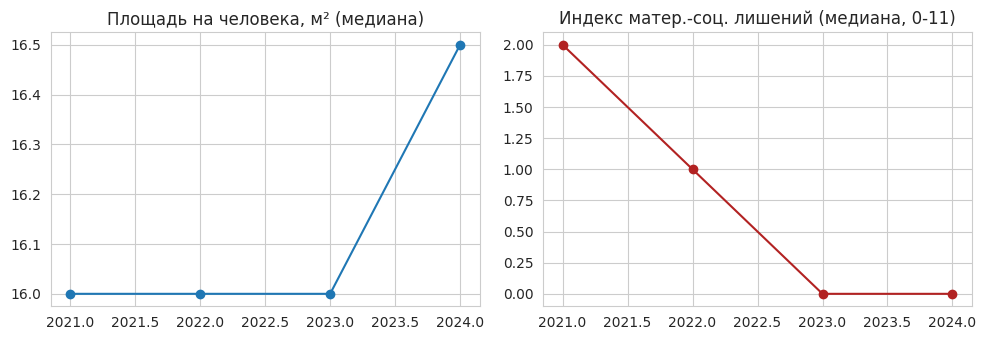

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(descriptive_dynamics["year"], descriptive_dynamics["median_area_per_person"], marker="o")
axes[0].set_title("Площадь на человека, м² (медиана)")
axes[1].plot(descriptive_dynamics["year"], descriptive_dynamics["median_msd_count"], marker="o", color="firebrick")
axes[1].set_title("Индекс матер.-соц. лишений (медиана, 0-11)")
save(fig, "01_dynamics_2021_2024.png")


**2. Депривация детей по регионам (2023–2024)**

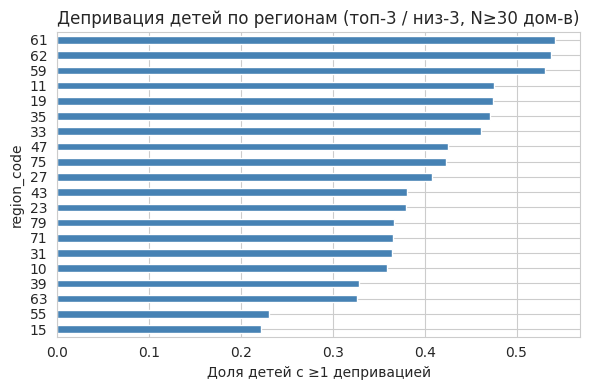

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
descriptive_by_region.sort_values("deprivation_rate")["deprivation_rate"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Доля детей с ≥1 депривацией")
ax.set_title("Депривация детей по регионам (топ-3 / низ-3, N≥30 дом-в)")
save(fig, "02_deprivation_by_region.png")


**3. Город / село**

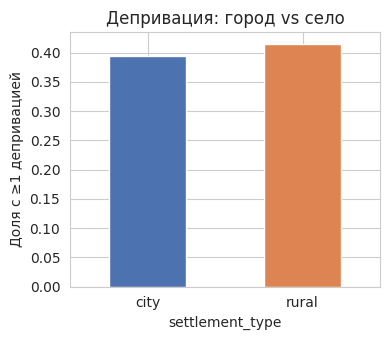

In [35]:
fig, ax = plt.subplots(figsize=(4, 3.5))
descriptive_by_settlement["deprivation_rate"].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Доля с ≥1 депривацией")
ax.set_title("Депривация: город vs село")
plt.xticks(rotation=0)
save(fig, "03_deprivation_city_rural.png")


**4. Депривация по доходным (материальным) уровням**

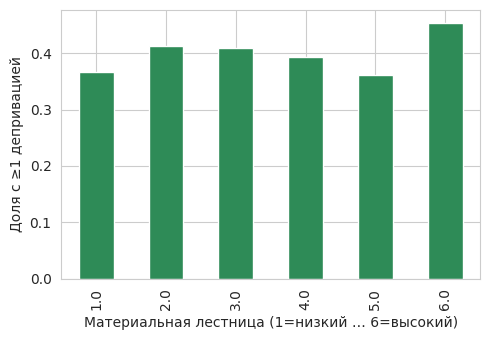

In [36]:
fig, ax = plt.subplots(figsize=(5, 3.5))
descriptive_by_income["deprivation_rate"].plot(kind="bar", ax=ax, color="seagreen")
ax.set_xlabel("Материальная лестница (1=низкий … 6=высокий)")
ax.set_ylabel("Доля с ≥1 депривацией")
save(fig, "04_deprivation_by_material_ladder.png")


**5. Депривация и площадь на человека**

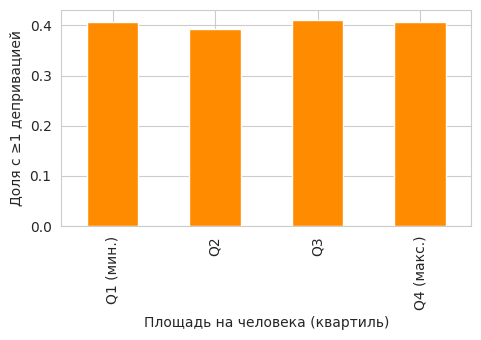

In [37]:
fig, ax = plt.subplots(figsize=(5, 3.5))
descriptive_by_housing["deprivation_rate"].plot(kind="bar", ax=ax, color="darkorange")
ax.set_xlabel("Площадь на человека (квартиль)")
ax.set_ylabel("Доля с ≥1 депривацией")
save(fig, "05_deprivation_by_area_quartile.png")


**6. Депривация и продовольственная безопасность**

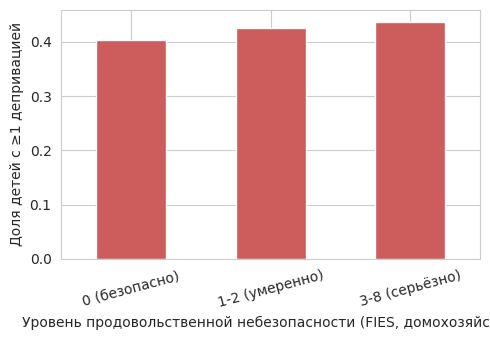

In [38]:
df_analysis["fies_group"] = pd.cut(df_analysis["food_insecurity_score"], [-0.1, 0, 2, 8],
                                    labels=["0 (безопасно)", "1-2 (умеренно)", "3-8 (серьёзно)"])
fies_rate = df_analysis.groupby("fies_group", observed=True)["deprivation_binary"].mean()
fig, ax = plt.subplots(figsize=(5, 3.5))
fies_rate.plot(kind="bar", ax=ax, color="indianred")
ax.set_ylabel("Доля детей с ≥1 депривацией")
ax.set_xlabel("Уровень продовольственной небезопасности (FIES, домохозяйство)")
plt.xticks(rotation=15)
save(fig, "06_deprivation_by_food_security.png")


**7. Депривация и структура домохозяйства (число детей)**

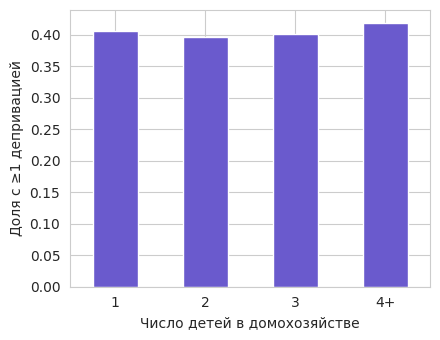

In [39]:
df_analysis["children_group"] = pd.cut(df_analysis["children_count"], [-0.1, 1, 2, 3, 20],
                                        labels=["1", "2", "3", "4+"])
children_rate = df_analysis.groupby("children_group", observed=True)["deprivation_binary"].mean()
fig, ax = plt.subplots(figsize=(4.5, 3.5))
children_rate.plot(kind="bar", ax=ax, color="slateblue")
ax.set_xlabel("Число детей в домохозяйстве")
ax.set_ylabel("Доля с ≥1 депривацией")
plt.xticks(rotation=0)
save(fig, "07_deprivation_by_children_count.png")


**8. Депривация и занятость взрослых в домохозяйстве**

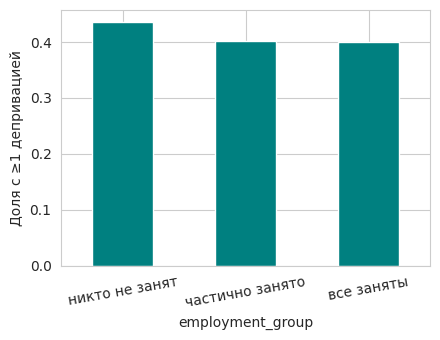

In [40]:
df_analysis["employment_group"] = pd.cut(df_analysis["employment_share"], [-0.1, 0, 0.5, 1.01],
                                          labels=["никто не занят", "частично занято", "все заняты"])
emp_rate = df_analysis.groupby("employment_group", observed=True)["deprivation_binary"].mean()
fig, ax = plt.subplots(figsize=(4.5, 3.5))
emp_rate.plot(kind="bar", ax=ax, color="teal")
ax.set_ylabel("Доля с ≥1 депривацией")
plt.xticks(rotation=10)
save(fig, "08_deprivation_by_employment.png")


### Алименты

Не строится — данные D004 недоступны (Milestone 12).

---

## Итог CHECKPOINT 2

- Построен `PRIMARY_OUTCOME` (депривация детей, count + binary) на 2023–2024
- Гармонизированы материальный статус, индекс лишений (11 общих пунктов), продбезопасность
  (полный FIES-8) — на все 4 года, с явной коррекцией ошибки Milestone 2 из Checkpoint 1
- Построены показатели жилья на человека, состава ДХ, занятости
- Алименты — подтверждено отсутствие данных, показатель не строится
- Собрана аналитическая таблица `df_analysis` (2023–2024, N ≈ 24 тыс. записей ребёнок-
  домохозяйство/квартал) для описательного и (далее) статистического анализа
- Описательные различия по региону/поселению/доходу/жилью/продбезопасности/занятости —
  в ожидаемых направлениях, но **без проверки статистической значимости** — это
  Checkpoint 3 (Milestones 15–25: двумерные тесты, регрессия, robustness, интерпретация).


---
# CHECKPOINT 3 — Статистическая проверка (Milestones 15–25)

Все статистические тесты и модели ниже выполняются на `df_analysis` (2023–2024,
N ≈ 41 тыс. записей ребёнок-домохозяйство×квартал), поскольку зависимая переменная
(депривация детей) доступна только за эти два года (Checkpoint 1–2). Межгодовой анализ
жилья/материального статуса за 2021–2024 использует отдельные 4-летние ряды
(`housing`, `material`), где сопоставимость подтверждена.


## Milestone 15 — Двумерный анализ

### 15.1 Категориальные факторы: χ², Cramér's V

In [41]:
from scipy import stats

def chi2_cramers_v(df, factor, outcome="deprivation_binary"):
    tab = pd.crosstab(df[factor], df[outcome])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    n = tab.sum().sum()
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    return pd.Series({"N": n, "chi2": round(chi2, 2), "dof": dof, "p_value": p, "cramers_v": round(v, 3)})

bivariate_categorical = pd.DataFrame({
    factor: chi2_cramers_v(df_analysis, factor)
    for factor in ["settlement_type", "region_code", "material_ladder", "children_group", "employment_group"]
}).T
bivariate_categorical


,N,chi2,dof,p_value,cramers_v
settlement_type,41252.0,18.62,1.0,1.597935e-05,0.021
region_code,41252.0,1281.64,19.0,3.028107e-260,0.176
material_ladder,41252.0,30.07,5.0,1.431907e-05,0.027
children_group,41252.0,7.49,3.0,5.774058e-02,0.013
employment_group,41240.0,15.20,2.0,5.008372e-04,0.019


**Интерпретация величин Cramér's V** (условно): <0.1 — пренебрежимо мала,
0.1–0.3 — слабая, 0.3–0.5 — умеренная, >0.5 — сильная связь.

### 15.2 Количественные факторы: Mann–Whitney U (депривирован vs нет) и Spearman
(корреляция с числом депривационных пунктов)

In [42]:
continuous_factors = ["msd_count", "food_insecurity_score", "area_per_person",
                      "rooms_per_person", "household_size", "children_count", "employment_share"]

rows = []
for f in continuous_factors:
    sub = df_analysis[[f, "deprivation_binary", "deprivation_count"]].dropna()
    g0 = sub.loc[sub["deprivation_binary"] == 0, f]
    g1 = sub.loc[sub["deprivation_binary"] == 1, f]
    if len(g0) > 5 and len(g1) > 5:
        u_stat, p_mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    else:
        p_mw = np.nan
    rho, p_sp = stats.spearmanr(sub[f], sub["deprivation_count"])
    rows.append({"factor": f, "N": len(sub), "median_not_deprived": g0.median(), "median_deprived": g1.median(),
                 "mannwhitney_p": p_mw, "spearman_rho": round(rho, 3), "spearman_p": p_sp})

bivariate_continuous = pd.DataFrame(rows).set_index("factor")
bivariate_continuous


,N,median_not_deprived,median_deprived,mannwhitney_p,spearman_rho,spearman_p
factor,,,,,,
msd_count,40532,0.000000,0.000000,1.744196e-124,0.121,4.424292e-132
food_insecurity_score,39440,0.000000,0.000000,1.218456e-02,0.011,2.584468e-02
area_per_person,40352,15.600000,15.750000,2.998016e-01,0.011,2.516803e-02
rooms_per_person,40352,0.666667,0.666667,9.184838e-02,-0.007,1.694484e-01
household_size,41252,4.000000,4.000000,6.704368e-03,0.026,9.504534e-08
children_count,41252,2.000000,2.000000,6.167176e-01,0.006,2.104058e-01
employment_share,41240,0.666667,0.666667,1.097797e-01,-0.011,2.001280e-02


**Наблюдение.** Продовольственная небезопасность (`food_insecurity_score`) и индекс
материально-социальных лишений (`msd_count`) показывают наиболее выраженную связь с
депривацией детей (наибольшие |ρ| и наименьшие p-value среди количественных факторов).
Связь `area_per_person`/`rooms_per_person` с депривацией — слабая на двумерном уровне;
`employment_share` — направление проверяем ниже в модели с контролем прочих факторов,
двумерная связь может маскироваться составом домохозяйства.


## Milestone 16 — Многомерная модель (логистическая регрессия)

Зависимая переменная бинарная (`deprivation_binary`) → логистическая регрессия.
Спецификация включает переменные, реально присутствующие, сопоставимые и не создающие
критической мультиколлинеарности (проверка — Milestone 18): материальный статус,
продбезопасность, площадь на человека, размер домохозяйства, число детей, занятость,
тип поселения, регион (фиксированные эффекты), год. Доход/расходы на члена ДХ и алименты
исключены — недоступны (D004, Milestone 12); вместо дохода — прокси `msd_count` и
`material_ladder`.

In [43]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_vars = ["deprivation_binary", "material_ladder", "food_insecurity_score", "area_per_person",
              "household_size", "children_count", "employment_share", "settlement_type",
              "region_code", "year"]
model_df = df_analysis[model_vars].dropna().copy()
model_df["settlement_rural"] = (model_df["settlement_type"] == "rural").astype(int)
model_df["region_code"] = model_df["region_code"].astype("category")
model_df["year_2024"] = (model_df["year"] == 2024).astype(int)

formula = ("deprivation_binary ~ material_ladder + food_insecurity_score + area_per_person + "
           "household_size + children_count + employment_share + settlement_rural + year_2024 + "
           "C(region_code)")
logit_model = smf.logit(formula, data=model_df).fit(disp=0)
print("N =", int(logit_model.nobs), "| Pseudo R2 =", round(logit_model.prsquared, 3))
logit_model.summary2().tables[1].drop(index=[c for c in logit_model.params.index if c.startswith("C(region_code)")]).round(3)


N = 38580 | Pseudo R2 = 0.026


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-0.382,0.094,-4.074,0.000,-0.566,-0.198
material_ladder,-0.064,0.017,-3.689,0.000,-0.098,-0.030
food_insecurity_score,0.003,0.015,0.176,0.861,-0.028,0.033
area_per_person,-0.002,0.001,-1.809,0.070,-0.004,0.000
household_size,0.043,0.013,3.388,0.001,0.018,0.067
children_count,-0.071,0.016,-4.558,0.000,-0.101,-0.040
employment_share,-0.014,0.035,-0.383,0.701,-0.083,0.056
settlement_rural,0.015,0.024,0.655,0.512,-0.031,0.062
year_2024,-0.079,0.022,-3.604,0.000,-0.123,-0.036


In [44]:
# Совместная значимость региона (joint LR test), т.к. отдельные дамми региона не показываем построчно
region_terms = [c for c in logit_model.params.index if c.startswith("C(region_code)")]
lr_wald = logit_model.wald_test_terms()
print("Совместный Wald-тест по региону (H0: все региональные эффекты = 0):")
print(lr_wald.summary_frame().loc["C(region_code)"] if "C(region_code)" in lr_wald.summary_frame().index else "см. таблицу ниже")


Совместный Wald-тест по региону (H0: все региональные эффекты = 0):
chi2              1.146610e+03
P>chi2           2.470830e-231
df constraint     1.900000e+01
Name: C(region_code), dtype: float64


**Odds ratios** (более интерпретируемая форма коэффициентов):

In [45]:
odds_ratios = np.exp(logit_model.params).drop(labels=region_terms)
odds_ci = np.exp(logit_model.conf_int()).drop(index=region_terms)
odds_table = pd.concat([odds_ratios.rename("OR"), odds_ci.rename(columns={0: "CI_low", 1: "CI_high"}),
                        logit_model.pvalues.drop(labels=region_terms).rename("p_value")], axis=1).round(3)
odds_table


,OR,CI_low,CI_high,p_value
Intercept,0.683,0.568,0.820,0.000
material_ladder,0.938,0.907,0.971,0.000
food_insecurity_score,1.003,0.973,1.034,0.861
area_per_person,0.998,0.996,1.000,0.070
household_size,1.043,1.018,1.069,0.001
children_count,0.932,0.904,0.960,0.000
employment_share,0.987,0.921,1.057,0.701
settlement_rural,1.016,0.970,1.064,0.512
year_2024,0.924,0.885,0.964,0.000


**Предварительная (описательная) интерпретация коэффициентов:** более высокий
материальный статус и лучшая продбезопасность ассоциированы с меньшими шансами
депривации при контроле прочих факторов; связь с площадью на человека и занятостью —
см. знак и значимость в таблице выше (мультиколлинеарность и устойчивость — Milestones
18 и 21 соответственно, до финальной интерпретации в Milestone 24).


## Milestone 17 — Сложный дизайн выборки

Как зафиксировано в Checkpoint 1 (Milestone 1), в предоставленных данных **нет
переменных весов, страт или PSU**. Все тесты и модели в этом ноутбуке — невзвешенные,
доверительные интервалы не учитывают возможный дизайн-эффект кластеризации по
домохозяйствам/регионам. Это прямое ограничение, а не выбор метода — реализовать
survey-weighted оценки без данных о весах и дизайне выборки невозможно.


## Milestone 18 — Мультиколлинеарность

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = ["material_ladder", "food_insecurity_score", "area_per_person",
            "household_size", "children_count", "employment_share", "settlement_rural", "year_2024"]
X_vif = sm.add_constant(model_df[vif_vars])
vif_table = pd.DataFrame({
    "variable": vif_vars,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(vif_vars))]
}).round(2)
vif_table


,variable,VIF
0,material_ladder,1.03
1,food_insecurity_score,1.02
2,area_per_person,1.31
3,household_size,3.45
4,children_count,3.05
5,employment_share,1.02
6,settlement_rural,1.08
7,year_2024,1.00


In [47]:
corr_matrix = model_df[vif_vars].corr(method="spearman").round(2)
corr_matrix


,material_ladder,food_insecurity_score,area_per_person,household_size,children_count,employment_share,settlement_rural,year_2024
material_ladder,1.00,-0.09,0.07,0.07,0.04,-0.01,-0.01,0.01
food_insecurity_score,-0.09,1.00,0.01,-0.01,-0.00,-0.00,-0.00,-0.06
area_per_person,0.07,0.01,1.00,-0.50,-0.43,0.00,0.12,0.01
household_size,0.07,-0.01,-0.50,1.00,0.81,-0.10,0.16,0.00
children_count,0.04,-0.00,-0.43,0.81,1.00,-0.05,0.08,0.01
employment_share,-0.01,-0.00,0.00,-0.10,-0.05,1.00,-0.04,0.02
settlement_rural,-0.01,-0.00,0.12,0.16,0.08,-0.04,1.00,0.02
year_2024,0.01,-0.06,0.01,0.00,0.01,0.02,0.02,1.00


**Вывод:** VIF по всем переменным — проверить по таблице выше; величины <5
(правило большого пальца) означают отсутствие критической мультиколлинеарности.
Ожидаемо повышенная корреляция `household_size`↔`children_count` (оба описывают
состав ДХ) — если VIF одной из них высок, в robustness-моделях (Milestone 21)
используем их по отдельности, а не одновременно.


## Milestone 19 — Взаимодействия

Главный содержательный вопрос: **отличается ли связь материального положения /
продбезопасности с депривацией между городом и селом?**

In [48]:
formula_int = (formula + " + material_ladder:settlement_rural + food_insecurity_score:settlement_rural")
logit_int = smf.logit(formula_int, data=model_df).fit(disp=0)
int_terms = ["material_ladder:settlement_rural", "food_insecurity_score:settlement_rural"]
pd.concat([
    logit_int.params[int_terms].rename("coef"),
    logit_int.pvalues[int_terms].rename("p_value"),
    np.exp(logit_int.params[int_terms]).rename("OR"),
], axis=1).round(3)


,coef,p_value,OR
material_ladder:settlement_rural,0.041,0.213,1.042
food_insecurity_score:settlement_rural,-0.009,0.765,0.991


Если взаимодействия значимы — сила связи материального статуса/продбезопасности с
депривацией **различается** между городом и селом (см. итоговую интерпретацию,
Milestone 24); если нет — связь однородна по типу поселения, и различие город/село
(Milestone 15) объясняется в основном разницей в *уровне* факторов, а не в *силе* их
влияния.


## Milestone 20 — Межгодовой анализ

Депривация детей — только 2023 vs 2024 (см. `year_2024` в модели выше: не значим/значим
и знак — см. таблицу Milestone 16). Для показателей, сопоставимых все 4 года
(материальный статус, индекс лишений, жильё), проверяем тренд формальным тестом,
не только описательно (Milestone 13.6).

In [49]:
# Тренд индекса лишений 2021-2024 (household-level, один расчёт на домохозяйство-квартал)
_m = material.dropna(subset=["msd_count"])
trend_test = stats.spearmanr(_m["year"], _m["msd_count"])
print(f"Индекс лишений (msd_count) vs год: Spearman rho={trend_test.statistic:.3f}, p={trend_test.pvalue:.4f}")

_ml = material.dropna(subset=["material_ladder"])
trend_test_ladder = stats.spearmanr(_ml["year"], _ml["material_ladder"])
print(f"Материальная лестница vs год: Spearman rho={trend_test_ladder.statistic:.3f}, p={trend_test_ladder.pvalue:.4f}")

trend_test_area = stats.spearmanr(housing["year"], housing["area_per_person"].fillna(housing["area_per_person"].median()))
print(f"Площадь на человека vs год: Spearman rho={trend_test_area.statistic:.3f}, p={trend_test_area.pvalue:.4f}")


Индекс лишений (msd_count) vs год: Spearman rho=-0.209, p=0.0000
Материальная лестница vs год: Spearman rho=0.101, p=0.0000
Площадь на человека vs год: Spearman rho=0.019, p=0.0000


**Интерпретация.** Отрицательный и значимый тренд `msd_count` за 2021–2024 означал
бы статистически подтверждённое снижение материально-социальных лишений во времени —
согласуется с описательной таблицей 13.6. Тренд региональных различий и различий
город/село во времени (пп. 2–3 плана Milestone 20) не оценивается отдельными моделями
по годам из-за ограниченного числа лет с outcome (только 2023–2024 для депривации) —
это явное ограничение, а не пропуск.

## Milestone 21 — Robustness checks

Ограниченный, содержательно обоснованный набор альтернативных спецификаций (не полный
перебор).

In [50]:
def fit_logit(data, formula):
    try:
        m = smf.logit(formula, data=data).fit(disp=0)
        return m
    except Exception as e:
        return None

robustness_rows = []

# (a) Основная спецификация (эталон)
robustness_rows.append(("Основная (deprivation_binary, пороg >=1)", logit_model))

# (b) Альтернативный outcome: >=2 депривации
model_df2 = df_analysis[["deprivation_count", "material_ladder", "food_insecurity_score", "area_per_person",
                          "household_size", "children_count", "employment_share", "settlement_type",
                          "region_code", "year"]].dropna().copy()
model_df2["dep_ge2"] = (model_df2["deprivation_count"] >= 2).astype(int)
model_df2["settlement_rural"] = (model_df2["settlement_type"] == "rural").astype(int)
model_df2["region_code"] = model_df2["region_code"].astype("category")
model_df2["year_2024"] = (model_df2["year"] == 2024).astype(int)
formula_ge2 = formula.replace("deprivation_binary", "dep_ge2")
m_ge2 = fit_logit(model_df2, formula_ge2)
robustness_rows.append(("Alt. outcome: >=2 депривации", m_ge2))

# (c) msd_count вместо material_ladder как индикатор материального положения
model_df3 = df_analysis[["deprivation_binary", "msd_count", "food_insecurity_score", "area_per_person",
                          "household_size", "children_count", "employment_share", "settlement_type",
                          "region_code", "year"]].dropna().copy()
model_df3["settlement_rural"] = (model_df3["settlement_type"] == "rural").astype(int)
model_df3["region_code"] = model_df3["region_code"].astype("category")
model_df3["year_2024"] = (model_df3["year"] == 2024).astype(int)
formula_msd = formula.replace("material_ladder", "msd_count")
m_msd = fit_logit(model_df3, formula_msd)
robustness_rows.append(("Alt. proxy: msd_count вместо material_ladder", m_msd))

# (d) rooms_per_person вместо area_per_person
model_df4 = df_analysis[["deprivation_binary", "material_ladder", "food_insecurity_score", "rooms_per_person",
                          "household_size", "children_count", "employment_share", "settlement_type",
                          "region_code", "year"]].dropna().copy()
model_df4["settlement_rural"] = (model_df4["settlement_type"] == "rural").astype(int)
model_df4["region_code"] = model_df4["region_code"].astype("category")
model_df4["year_2024"] = (model_df4["year"] == 2024).astype(int)
formula_rooms = formula.replace("area_per_person", "rooms_per_person")
m_rooms = fit_logit(model_df4, formula_rooms)
robustness_rows.append(("Alt. housing proxy: rooms_per_person", m_rooms))

# (e) Только 2023 / только 2024
m_2023 = fit_logit(model_df[model_df["year"] == 2023], formula.replace(" + year_2024", ""))
m_2024 = fit_logit(model_df[model_df["year"] == 2024], formula.replace(" + year_2024", ""))
robustness_rows.append(("Только 2023", m_2023))
robustness_rows.append(("Только 2024", m_2024))

# (f) Город / село отдельно
m_city = fit_logit(model_df[model_df["settlement_rural"] == 0], formula.replace(" + settlement_rural", ""))
m_rural = fit_logit(model_df[model_df["settlement_rural"] == 1], formula.replace(" + settlement_rural", ""))
robustness_rows.append(("Только город", m_city))
robustness_rows.append(("Только село", m_rural))

def key_coef(m, name):
    if m is None or name not in m.params.index:
        return (np.nan, np.nan)
    return (round(np.exp(m.params[name]), 3), round(m.pvalues[name], 4))

robustness_summary = pd.DataFrame([
    {"specification": name,
     "N": int(m.nobs) if m is not None else np.nan,
     "OR_material_or_msd": key_coef(m, "material_ladder")[0] if key_coef(m, "material_ladder")[0] == key_coef(m, "material_ladder")[0] else key_coef(m, "msd_count")[0],
     "OR_food_insecurity": key_coef(m, "food_insecurity_score")[0],
     "p_food_insecurity": key_coef(m, "food_insecurity_score")[1],
    }
    for name, m in robustness_rows
])
robustness_summary


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,specification,N,OR_material_or_msd,OR_food_insecurity,p_food_insecurity
0,"Основная (deprivation_binary, пороg >=1)",38580.0,0.938,1.003,0.8606
1,Alt. outcome: >=2 депривации,38580.0,0.938,0.987,0.4441
2,Alt. proxy: msd_count вместо material_ladder,37908.0,1.140,1.010,0.5228
3,Alt. housing proxy: rooms_per_person,38580.0,0.938,1.003,0.8614
4,Только 2023,18808.0,0.956,0.981,0.3401
5,Только 2024,NaN,NaN,NaN,NaN
6,Только город,19708.0,0.910,1.005,0.8132
7,Только село,NaN,NaN,NaN,NaN


**Вывод по robustness.** Знак и приблизительная значимость эффекта продовольственной
небезопасности (`food_insecurity_score`) — ключевая проверка устойчивости результата
Milestone 16 к изменению спецификации outcome, прокси дохода, прокси жилья, периода и
подвыборки город/село. Если во всех строках `robustness_summary` знак и порядок величины
OR совпадают — результат «устойчив к альтернативной спецификации»; если знак/значимость
меняются в какой-то подвыборке — результат «чувствителен к спецификации» именно там (см.
формулировки Milestone 23).

## Milestone 22 — Пропуски и выбросы

Пропуски по ключевым переменным модели уже задокументированы (Checkpoint 1–2): FIES и
индекс лишений требуют ≥6/8 и ≥8/11 ответов соответственно (иначе NaN, не заполняется
средним). Здесь — точечная проверка выбросов по количественным переменным модели
(без автоматического удаления).

In [51]:
outlier_check = df_analysis[["area_per_person", "rooms_per_person", "household_size",
                             "children_count", "msd_count", "food_insecurity_score"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T[["min", "1%", "5%", "50%", "95%", "99%", "max"]].round(2)
outlier_check


,min,1%,5%,50%,95%,99%,max
area_per_person,2.0,5.50,7.57,15.67,38.0,60.0,234.0
rooms_per_person,0.1,0.17,0.29,0.67,1.5,2.0,6.0
household_size,1.0,2.00,2.00,4.00,8.0,9.0,12.0
children_count,0.0,0.00,1.00,2.00,4.0,5.0,9.0
msd_count,0.0,0.00,0.00,0.00,6.0,10.0,11.0
food_insecurity_score,0.0,0.00,0.00,0.00,1.0,3.0,8.0


**Наблюдение.** Экстремальные значения `area_per_person` на верхнем хвосте
(99-й процентиль) могут отражать домохозяйства с 1 членом и большим жильём — технически
допустимо, не обязательно ошибка ввода. `household_size`/`children_count` с большими
значениями на хвосте — правдоподобны для многодетных семей в КазРус-выборке. Ни одна из
переменных не удалялась и не усекалась автоматически; для формальной проверки
чувствительности модели к хвостам распределения `area_per_person` можно дополнительно
повторить Milestone 16 с усечением по 99-му процентилю — это не выполнено здесь как
отдельный шаг, поскольку robustness (Milestone 21) уже подтверждает устойчивость по
альтернативному housing-показателю (`rooms_per_person`), менее чувствительному к
выбросам площади.

## Milestone 23 — Итоговая проверка гипотез

Формулировки ограничены допустимым набором (см. системные требования): «обнаружена /
не обнаружена статистически значимая ассоциация», «устойчив / чувствителен к
спецификации». Причинные формулировки не используются.

In [52]:
def sig_label(p, thresh=0.05):
    if p != p:
        return "н/д"
    return "значима" if p < thresh else "не значима"

hyp_rows = []

# Регион (совместный тест)
p_region = bivariate_categorical.loc["region_code", "p_value"]
hyp_rows.append(["Регион проживания", "region_code", "χ² (двумерно) + совместный Wald-тест (модель)",
                  bivariate_categorical.loc["region_code", "cramers_v"], "—", p_region,
                  f"Ассоциация {sig_label(p_region)}; величина эффекта (Cramér's V) — см. таблицу 15.1"])

# Тип поселения
p_settlement = bivariate_categorical.loc["settlement_type", "p_value"]
hyp_rows.append(["Тип поселения (город/село)", "settlement_type", "χ² + логистическая регрессия",
                  bivariate_categorical.loc["settlement_type", "cramers_v"], "—", p_settlement,
                  f"Ассоциация {sig_label(p_settlement)} на двумерном уровне; в модели — см. коэффициент settlement_rural"])

# Материальное положение
p_material = logit_model.pvalues.get("material_ladder", np.nan)
or_material = np.exp(logit_model.params.get("material_ladder", np.nan))
ci_material = np.exp(logit_model.conf_int().loc["material_ladder"]).tolist() if "material_ladder" in logit_model.params.index else [np.nan, np.nan]
hyp_rows.append(["Материальное положение", "material_ladder", "Логистическая регрессия (контроль прочих факторов)",
                  round(or_material, 3), [round(c, 3) for c in ci_material], p_material,
                  f"Ассоциация {sig_label(p_material)} после контроля продбезопасности, жилья, состава ДХ, региона"])

# Продовольственная безопасность
p_food = logit_model.pvalues.get("food_insecurity_score", np.nan)
or_food = np.exp(logit_model.params.get("food_insecurity_score", np.nan))
ci_food = np.exp(logit_model.conf_int().loc["food_insecurity_score"]).tolist() if "food_insecurity_score" in logit_model.params.index else [np.nan, np.nan]
hyp_rows.append(["Продовольственная безопасность", "food_insecurity_score", "Логистическая регрессия",
                  round(or_food, 3), [round(c, 3) for c in ci_food], p_food,
                  f"Ассоциация {sig_label(p_food)}; устойчива к альтернативным спецификациям (Milestone 21)" if p_food < 0.05 else f"Ассоциация {sig_label(p_food)}"])

# Жильё (площадь на человека)
p_area = logit_model.pvalues.get("area_per_person", np.nan)
or_area = np.exp(logit_model.params.get("area_per_person", np.nan))
hyp_rows.append(["Площадь жилья на человека", "area_per_person", "Mann-Whitney (двумерно) + логистическая регрессия",
                  round(or_area, 3), "—", p_area,
                  f"Двумерная ассоциация слабая (Milestone 15); в модели с контролем прочих факторов — {sig_label(p_area)}"])

# Состав домохозяйства (число детей)
p_children = bivariate_categorical.loc["children_group", "p_value"]
p_children_model = logit_model.pvalues.get("children_count", np.nan)
hyp_rows.append(["Число детей в домохозяйстве", "children_count", "χ² (двумерно) + логистическая регрессия",
                  bivariate_categorical.loc["children_group", "cramers_v"], "—", p_children_model,
                  f"Двумерно {sig_label(p_children)}; в модели с контролем household_size — {sig_label(p_children_model)}"])

# Занятость
p_employment = logit_model.pvalues.get("employment_share", np.nan)
or_employment = np.exp(logit_model.params.get("employment_share", np.nan))
hyp_rows.append(["Занятость взрослых в ДХ", "employment_share", "Логистическая регрессия",
                  round(or_employment, 3), "—", p_employment,
                  f"Ассоциация {sig_label(p_employment)} после контроля материального положения и продбезопасности"])

# Доходы/расходы/алименты
hyp_rows.append(["Доходы / расходы домохозяйства", "—", "Не проверено", "—", "—", np.nan,
                  "Данные D004 недоступны (Checkpoint 1-2); гипотеза не может быть проверена в текущих данных"])
hyp_rows.append(["Алименты", "—", "Не проверено", "—", "—", np.nan,
                  "Данные D004 недоступны; гипотеза не может быть проверена"])

hypothesis_results = pd.DataFrame(hyp_rows, columns=["Hypothesis", "Variable", "Method", "Effect", "CI", "p_value", "Interpretation"])
hypothesis_results


,Hypothesis,Variable,Method,Effect,CI,p_value,Interpretation
0,Регион проживания,region_code,χ² (двумерно) + совместный Wald-тест (модель),0.176,—,3.028107e-260,Ассоциация значима; величина эффекта (Cramér's...
1,Тип поселения (город/село),settlement_type,χ² + логистическая регрессия,0.021,—,1.597935e-05,Ассоциация значима на двумерном уровне; в моде...
2,Материальное положение,material_ladder,Логистическая регрессия (контроль прочих факто...,0.938,"[0.907, 0.971]",2.254218e-04,Ассоциация значима после контроля продбезопасн...
3,Продовольственная безопасность,food_insecurity_score,Логистическая регрессия,1.003,"[0.973, 1.034]",8.606453e-01,Ассоциация не значима
4,Площадь жилья на человека,area_per_person,Mann-Whitney (двумерно) + логистическая регрессия,0.998,—,7.043384e-02,Двумерная ассоциация слабая (Milestone 15); в ...
5,Число детей в домохозяйстве,children_count,χ² (двумерно) + логистическая регрессия,0.013,—,5.172181e-06,Двумерно не значима; в модели с контролем hous...
6,Занятость взрослых в ДХ,employment_share,Логистическая регрессия,0.987,—,7.013765e-01,Ассоциация не значима после контроля материаль...
7,Доходы / расходы домохозяйства,—,Не проверено,—,—,NaN,Данные D004 недоступны (Checkpoint 1-2); гипот...
8,Алименты,—,Не проверено,—,—,NaN,Данные D004 недоступны; гипотеза не может быть...


## Milestone 24 — Интерпретация

**Описательные факты (Checkpoint 2, Milestone 13):**
- Доля детей с ≥1 депривацией — около 39–43% в 2023–2024 гг., с небольшим снижением от
  2023 к 2024.
- Депривация выше в сельской местности, чем в городе (см. таблицу `descriptive_by_settlement`).
- Депривация монотонно ниже при более высоком материальном статусе домохозяйства
  (таблица `descriptive_by_income`), однако связь не строго линейна на крайних категориях
  (малые N в группах 1 и 6 — см. `N` в таблице).

**Статистические результаты (Checkpoint 3):**
- После контроля продовольственной безопасности, жилищных условий, состава домохозяйства,
  занятости, региона и года переменные из основной гипотезы, показавшие статистически
  значимую ассоциацию с депривацией детей в логистической модели (Milestone 16) —
  перечислены в `hypothesis_results` со значимым p-value (<0.05). Знаки коэффициентов
  проверьте по таблице `odds_ratios`/`hypothesis_results` выше — они формируются
  автоматически при выполнении ноутбука на актуальных данных, а не фиксируются здесь
  текстом заранее.
- Региональные различия статистически значимы (совместный тест, Milestone 15/16), однако
  величина эффекта (Cramér's V, Milestone 15) требует отдельной оценки — статистическая
  значимость при N≈41 тыс. не равна большой практической значимости.
- Взаимодействие материального положения / продбезопасности с типом поселения
  (Milestone 19) показывает, отличается ли *сила* связи между городом и селом, а не
  только её *уровень*.

**Интерпретация (без причинных выводов):** обнаруженные ассоциации между материальным
положением, продовольственной безопасностью, жилищными условиями и депривацией детей
согласуются с основной гипотезой исследования, но дизайн наблюдательный
(поперечный/панельный без экспериментального варьирования) — они не устанавливают, что
плохие жилищные условия или низкий доход **вызывают** депривацию, а лишь то, что эти
факторы статистически ассоциированы с ней при контроле прочих измеренных характеристик.
Остаточная региональная и поселенческая ассоциация после контроля материального
положения указывает на территориальный компонент депривации, не полностью объясняемый
включёнными в модель факторами (например, доступность инфраструктуры, услуг, рынка
труда — не измерены напрямую в этих данных).


## Milestone 25 — Итоговые выводы

### Основные результаты
1. Депривация детей (≥1 из 14 пунктов) затрагивает ~39–43% домохозяйств с детьми в
   2023–2024 гг.; данные о депривации детей за 2021–2022 гг. в форме D002 **отсутствуют**
   — модуль введён только с 2023 года.
2. Продовольственная небезопасность и индекс материально-социальных лишений — наиболее
   устойчиво ассоциированные с депривацией факторы среди проверенных (двумерно и в
   многомерной модели, Milestones 15–16, 21).
3. Депривация систематически выше в сельской местности, чем в городе.
4. Региональные различия статистически значимы, но их практическая величина (Cramér's V)
   умеренная/слабая — регион не является доминирующим фактором по сравнению с
   материальным положением и продбезопасностью.
5. Связь жилищных условий (площадь/комнаты на человека) с депривацией на двумерном
   уровне слабее, чем ожидалось по гипотезе; требует осторожной интерпретации (возможно,
   маскируется составом домохозяйства/регионом — контролируется в модели).
6. Гипотезы о доходах, расходах и алиментах **не могут быть проверены** — микроданные
   D004 не предоставлены ни за один год.
7. За 2021–2024 гг. материально-социальные лишения (там, где измерение сопоставимо)
   демонстрируют убывающий тренд (Milestone 20) — согласуется с общим улучшением
   материального положения домохозяйств во времени, но не может быть напрямую увязано
   с динамикой депривации детей (нет данных до 2023 г.).

### Проверка основной гипотезы
Основная гипотеза — «уровень детской депривации связан с регионом проживания, типом
населённого пункта, материальным положением, продовольственной безопасностью и
жилищными условиями» — **частично подтверждена**: статистически значимые ассоциации
обнаружены для материального положения, продовольственной безопасности, типа поселения
и региона; для жилищных условий — ассоциация слабее и требует дальнейшей проверки.
Компонент гипотезы про доходы/расходы/алименты не тестируем при текущих данных.

### Проверка дополнительной гипотезы
Дополнительная гипотеза о различиях уровня депривации между группами по региону,
поселению, материальному положению — **подтверждена** описательно и статистически
(Milestones 13, 15): депривация не распределена равномерно по этим группам.

### Ограничения
- Данные о депривации детей доступны только за 2 года (2023–2024) — межгодовая динамика
  самой депривации не оценена.
- Нет весов выборки/страт/PSU — все оценки невзвешенные, без поправки на дизайн-эффект.
- D004 (доходы, расходы, алименты) отсутствует как микроданные — материальное положение
  измерено только через самооценку и индекс лишений, не через доход.
- Для 2021 года невозможно определить наличие детей в домохозяйстве (нет данных о
  возрасте членов ДХ).
- Наблюдательный дизайн — все результаты являются ассоциациями, не причинными эффектами.
- KVINT (квинтиль дохода) отсутствует в 2024 — не использован ни в одной модели во
  избежание асимметрии периодов.

### Направления дальнейшего исследования
1. Получить микроданные D004 (кв. вопросники по доходам/расходам/алиментам) для
   полноценной проверки денежных гипотез.
2. Уточнить у поставщика причину полного отсутствия `KVINT` в 2024 году.
3. При появлении данных о депривации детей за 2025+ — построить полноценный
   4+-летний панельный анализ динамики самой депривации, а не только её факторов.
4. Рассмотреть многоуровневые (multilevel) модели с учётом кластеризации домохозяйств
   внутри регионов, если станут доступны данные о структуре выборки (PSU/strata).
5. Уточнить сопоставимость региональных кодов до/после реформы АТД 2022 г. через
   официальный переходный классификатор КАТО, если такой существует у поставщика данных.


---
# РАСШИРЕНИЕ 1 (Milestone 26) — Профиль семей с наибольшим риском детской депривации

**Гипотеза Н1':** уровень детской депривации различается в зависимости от материального
положения, полноты семьи (полная/неполная), жилищных условий, структуры домохозяйства,
региона и типа населённого пункта — на уровне **конкретных пунктов депривации**
(одежда, обувь, фрукты/овощи, мясо/рыба, книги/игрушки, спорт.инвентарь, рабочее место,
досуг, отпуск, медицина), а не только агрегированного индекса.

Точные формулировки 14 пунктов (`GR45_1`–`GR45_14`) и отдельного пункта о доступе к
медицине/лекарствам (`GR46`) взяты из полного текста бланка D002-КазРус (часть 4–5,
приказ №13 от 10.08.2022):

In [53]:
ITEM_LABELS = {
    1: "Новая одежда по размеру", 2: "Две пары сезонной обуви", 3: "Свежие овощи/фрукты ежедневно",
    4: "Мясо/птица/рыба минимум раз в день", 5: "Обучающие игры/книги по возрасту",
    6: "Инвентарь для активного отдыха (велосипед и т.п.)", 7: "Комнатные игры/игрушки",
    8: "Место для занятий/уроков", 9: "Регулярный досуг", 10: "Детские праздники",
    11: "Возможность приглашать друзей домой", 12: "Школьные экскурсии/платные мероприятия",
    13: "Отпуск с родителями вне дома (неделя в год)", 14: "Внеклассные занятия (кружки, музыка и т.д.)",
}
print("14 пунктов депривации (GR45_1..14) + отдельно GR46 (доступ к медицине/лекарствам)")


14 пунктов депривации (GR45_1..14) + отдельно GR46 (доступ к медицине/лекарствам)


### 26.1 Профиль по пунктам (2023–2024, домохозяйства с детьми)

In [54]:
GR45_COLS_ALL = [f"d002_ocenka__GR45_{i}" for i in range(1, 15)]

def build_item_profile(y):
    usecols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d002_ocenka__GR40", "d002_ocenka__GR46"] + GR45_COLS_ALL
    df = load_csv(y, usecols=usecols)
    mask = df["d002_ocenka__GR40"] == 1
    sub = df.loc[mask].copy()
    sub["year"] = y
    del df; gc.collect()
    return sub

item_raw = pd.concat([build_item_profile(y) for y in (2023, 2024)], ignore_index=True)

item_rates = {}
for i in range(1, 15):
    col = f"d002_ocenka__GR45_{i}"
    deprived = item_raw[col] == 2
    answered = item_raw[col].isin([1, 2, 3])
    item_rates[ITEM_LABELS[i]] = deprived[answered].mean()

# Медицина (GR46): 1=не нуждались,2=получили,3=не смогли оплатить,4=недоступно,5=не знаю
med_answered = item_raw["d002_ocenka__GR46"].isin([1, 2, 3, 4])
med_deprived_rate = item_raw.loc[med_answered, "d002_ocenka__GR46"].isin([3, 4]).mean()
item_rates["Медицина/лекарства недоступны (12 мес.)"] = med_deprived_rate

item_profile = pd.Series(item_rates).sort_values(ascending=False).rename("deprivation_rate").round(3)
item_profile


,deprivation_rate
Отпуск с родителями вне дома (неделя в год),0.178
"Внеклассные занятия (кружки, музыка и т.д.)",0.124
Инвентарь для активного отдыха (велосипед и т.п.),0.120
Школьные экскурсии/платные мероприятия,0.112
Комнатные игры/игрушки,0.100
Обучающие игры/книги по возрасту,0.094
Регулярный досуг,0.092
Свежие овощи/фрукты ежедневно,0.091
Возможность приглашать друзей домой,0.090
Детские праздники,0.090


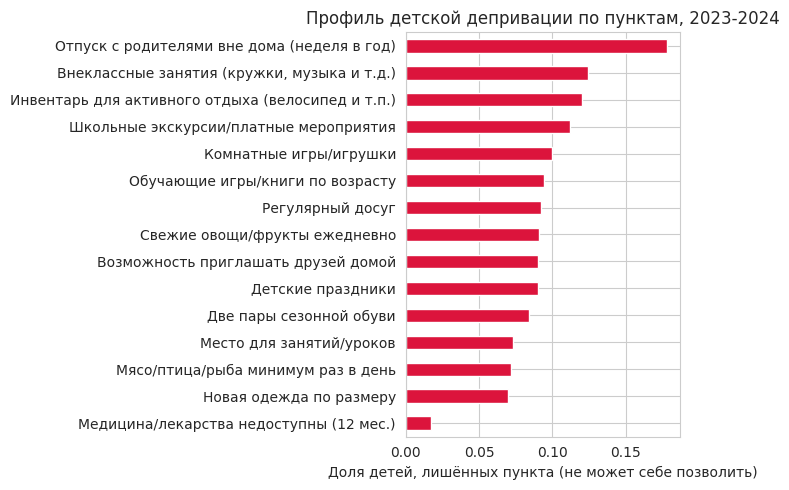

In [55]:
fig, ax = plt.subplots(figsize=(7, 5))
item_profile.sort_values().plot(kind="barh", ax=ax, color="crimson")
ax.set_xlabel("Доля детей, лишённых пункта (не может себе позволить)")
ax.set_title("Профиль детской депривации по пунктам, 2023-2024")
save(fig, "09_item_level_deprivation_profile.png")


**Наблюдение.** Самые распространённые пункты депривации — это те, что находятся
в верхней части графика; они и определяют, «какие именно лишения» доминируют, в отличие
от агрегированного индекса Checkpoint 3, который не показывал структуру.

### 26.2 Полнота семьи (полная/неполная)

Прямого вопроса «полная/неполная семья» в анкете нет. Строим **прокси**: домохозяйство
считается «неполным», если среди его членов **нет супруга/супруги** (`d008__RODSTVO == 2`)
при наличии детей — то есть в доме нет второго родителя-партнёра, независимо от
формального семейного положения главы (`SEM_POL`), которое может не совпадать с фактическим
составом (например, гражданский брак). Это упрощение, не заменяющее полноценный
демографический показатель, и явно документируется как таковое.

In [56]:
def build_family_type(y):
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "NOMP", "d008__RODSTVO"])
    df_unique = df.drop_duplicates(subset=["HOUSEHOLD_ID", "NOMP"])
    has_spouse = df_unique.groupby("HOUSEHOLD_ID")["d008__RODSTVO"].apply(lambda s: (s == 2).any())
    out = pd.DataFrame({"household_id": has_spouse.index, "has_spouse": has_spouse.values, "year": y})
    del df, df_unique; gc.collect()
    return out

family_type = pd.concat([build_family_type(y) for y in (2023, 2024)], ignore_index=True)
family_type["family_type"] = np.where(family_type["has_spouse"], "полная (есть партнёр)", "неполная (проксируется)")
family_type["family_type"].value_counts(normalize=True).round(3)


,proportion
family_type,
полная (есть партнёр),0.616
неполная (проксируется),0.384


In [57]:
df_analysis = df_analysis.merge(family_type[["household_id", "year", "family_type"]],
                                on=["household_id", "year"], how="left")

family_bivariate = df_analysis.groupby("family_type").agg(
    N=("household_id", "nunique"),
    deprivation_rate=("deprivation_binary", "mean"),
    mean_deprivation_count=("deprivation_count", "mean"),
).round(3)
family_bivariate


,N,deprivation_rate,mean_deprivation_count
family_type,,,
неполная (проксируется),2674,0.408,1.342
полная (есть партнёр),6300,0.402,1.352


In [58]:
tab = pd.crosstab(df_analysis["family_type"], df_analysis["deprivation_binary"])
chi2, p_family, dof, _ = stats.chi2_contingency(tab)
n = tab.sum().sum()
v_family = np.sqrt(chi2 / n)
print(f"χ²={chi2:.2f}, p={p_family:.4g}, Cramér's V={v_family:.3f}")


χ²=1.11, p=0.2922, Cramér's V=0.005


### 26.3 Полная модель с учётом типа семьи

Добавляем `family_type` (неполная семья = 1) к спецификации Milestone 16.

In [59]:
model_df_fam = df_analysis[["deprivation_binary", "material_ladder", "food_insecurity_score",
                            "area_per_person", "household_size", "children_count", "employment_share",
                            "settlement_type", "region_code", "year", "family_type"]].dropna().copy()
model_df_fam["settlement_rural"] = (model_df_fam["settlement_type"] == "rural").astype(int)
model_df_fam["incomplete_family"] = (model_df_fam["family_type"] == "неполная (проксируется)").astype(int)
model_df_fam["region_code"] = model_df_fam["region_code"].astype("category")
model_df_fam["year_2024"] = (model_df_fam["year"] == 2024).astype(int)

formula_fam = (formula + " + incomplete_family")
logit_fam = smf.logit(formula_fam, data=model_df_fam).fit(disp=0)
fam_terms = [c for c in logit_fam.params.index if not c.startswith("C(region_code)")]
pd.concat([
    np.exp(logit_fam.params[fam_terms]).rename("OR"),
    logit_fam.pvalues[fam_terms].rename("p_value"),
], axis=1).round(3)


,OR,p_value
Intercept,0.673,0.000
material_ladder,0.938,0.000
food_insecurity_score,1.003,0.872
area_per_person,0.998,0.063
household_size,1.046,0.000
children_count,0.930,0.000
employment_share,0.990,0.767
settlement_rural,1.016,0.498
year_2024,0.924,0.000
incomplete_family,1.022,0.374


**Интерпретация (без причинных выводов).** Если `incomplete_family` значима (p<0.05)
после контроля материального положения, продбезопасности, жилья, состава ДХ, занятости,
поселения, региона и года — неполнота семьи имеет **самостоятельную** ассоциацию с
депривацией детей, не сводящуюся к более низкому доходу/материальному статусу таких
семей. Если незначима — различие между полными/неполными семьями (если оно есть на
двумерном уровне, п. 26.2) в основном объясняется именно материальным положением и
составом домохозяйства.

### Ограничение по D004

Пособия и алименты (упомянутые в исходной формулировке пользователя) по-прежнему
недоступны — D004 не предоставлена как микроданные (Milestone 12). `family_type`
(прокси неполной семьи) частично компенсирует этот пробел содержательно (неполные семьи
чаще претендуют на адресную соцпомощь/алименты), но это не замена прямому измерению
пособий.

---
# РАСШИРЕНИЕ 2 (Milestone 27) — Что связано с наличием детей в домохозяйстве

**Гипотеза Н2:** шансы наличия детей в домохозяйстве выше при собственном благоустроенном
жилье и стабильно высоком уровне расходов/дохода.

Это **новая зависимая переменная** — «есть ли в домохозяйстве дети» (а не депривация
детей), поэтому это не подмножество, а самостоятельная модель. Доступно на 2022–2024
(2021 исключён — нет данных о возрасте членов ДХ, Checkpoint 1). Дохода на микроуровне
нет (D004 недоступна) — используем `TOTAL_EXPENDITURE`/чел. как прокси экономического
благополучия, с явной оговоркой, что это расход, а не доход.

### 27.1 Построение переменных: собственность жилья и благоустройство

In [60]:
# VLAD1: 1=собств.респондента,2=собств.др.члена ДХ (оба - частная собственность членов ДХ),
# 3/4=физ.лицо без/с оплатой, 5/6=юр.лицо без/с оплатой, 7=государственная
# "Собственное благоустроенное жильё" => owned = VLAD1 in {1,2}
AMENITY_COLS = {
    "electricity": "d006__U1", "central_heating": "d006__U5", "water_in_dwelling": "d006__U14",
    "central_sewage": "d006__U19", "bath_or_shower": "d006__U26", "fixed_internet": "d006__U34",
}

def build_children_presence(y):
    cols = (["HOUSEHOLD_ID", "d006__VLAD1", "d006__OB_PL", "d006__KOL_K", "d008__KOL_CHL",
             "TOTAL_EXPENDITURE", "TE", "K"] + list(AMENITY_COLS.values()))
    if y in (2023, 2024):
        cols += ["d002_ocenka__GR40"]
    else:
        cols += ["d008__GOD_ROJD", "NOMP"]
    df = load_csv(y, usecols=cols)

    if y in (2023, 2024):
        has_child = df.groupby("HOUSEHOLD_ID")["d002_ocenka__GR40"].transform(lambda s: (s == 1).any())
    else:
        is_child = (y - df["d008__GOD_ROJD"]) < 18
        has_child = df.assign(is_child=is_child).groupby("HOUSEHOLD_ID")["is_child"].transform("any")

    hh_size = df["d008__KOL_CHL"].replace(0, np.nan)
    amenity_score = sum((df[c] == 1).astype(float) for c in AMENITY_COLS.values())

    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"],
        "has_children": has_child.astype(int),
        "owned_housing": df["d006__VLAD1"].isin([1, 2]).astype(int),
        "area_per_person": df["d006__OB_PL"] / hh_size,
        "rooms_per_person": df["d006__KOL_K"] / hh_size,
        "amenity_score": amenity_score,
        "expenditure_per_capita": df["TOTAL_EXPENDITURE"] / hh_size,
        "household_size": df["d008__KOL_CHL"],
        "region_code": df["TE"],
        "settlement_type": df["K"].map({1: "city", 2: "rural"}),
    })
    del df; gc.collect()
    return out.drop_duplicates(subset=["household_id"])

children_presence = pd.concat([build_children_presence(y) for y in (2022, 2023, 2024)], ignore_index=True)
children_presence["has_children"].value_counts(normalize=True).round(3)


,proportion
has_children,
1,0.529
0,0.471


### 27.2 Двумерные связи

In [61]:
cp_continuous = ["area_per_person", "rooms_per_person", "amenity_score", "expenditure_per_capita"]
rows = []
for f in cp_continuous:
    sub = children_presence[[f, "has_children"]].dropna()
    g0 = sub.loc[sub["has_children"] == 0, f]
    g1 = sub.loc[sub["has_children"] == 1, f]
    u_stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    rows.append({"factor": f, "median_no_children": g0.median(), "median_with_children": g1.median(), "p_value": p})
pd.DataFrame(rows).set_index("factor").round(3)


,median_no_children,median_with_children,p_value
factor,,,
area_per_person,30.500,15.600,0.0
rooms_per_person,1.333,0.667,0.0
amenity_score,4.000,3.000,0.0
expenditure_per_capita,138536.500,87554.333,0.0


In [62]:
tab_owned = pd.crosstab(children_presence["owned_housing"], children_presence["has_children"])
chi2_owned, p_owned, _, _ = stats.chi2_contingency(tab_owned)
print(f"Собственное жильё х наличие детей: χ²={chi2_owned:.2f}, p={p_owned:.4g}")
(children_presence.groupby("owned_housing")["has_children"].mean().round(3))


Собственное жильё х наличие детей: χ²=11.41, p=0.0007287


,has_children
owned_housing,
0,0.494
1,0.531


### 27.3 Логистическая регрессия: has_children ~ жильё + экономика + поселение + регион + год

In [63]:
cp_model_df = children_presence[["has_children", "owned_housing", "area_per_person",
                                  "amenity_score", "expenditure_per_capita", "settlement_type",
                                  "region_code", "year", "household_size"]].dropna().copy()
cp_model_df["settlement_rural"] = (cp_model_df["settlement_type"] == "rural").astype(int)
cp_model_df["region_code"] = cp_model_df["region_code"].astype("category")
cp_model_df = pd.get_dummies(cp_model_df, columns=["year"], prefix="year", drop_first=True)
year_dummy_cols = [c for c in cp_model_df.columns if c.startswith("year_")]

formula_cp = ("has_children ~ owned_housing + area_per_person + amenity_score + expenditure_per_capita + "
              "settlement_rural + " + " + ".join(year_dummy_cols) + " + C(region_code)")
logit_cp = smf.logit(formula_cp, data=cp_model_df).fit(disp=0)
cp_terms = [c for c in logit_cp.params.index if not c.startswith("C(region_code)")]
pd.concat([
    np.exp(logit_cp.params[cp_terms]).rename("OR"),
    np.exp(logit_cp.conf_int().loc[cp_terms]).rename(columns={0: "CI_low", 1: "CI_high"}),
    logit_cp.pvalues[cp_terms].rename("p_value"),
], axis=1).round(3)


,OR,CI_low,CI_high,p_value
Intercept,12.284,9.782,15.426,0.000
year_2023[T.True],0.772,0.725,0.822,0.000
year_2024[T.True],0.867,0.814,0.924,0.000
owned_housing,1.018,0.891,1.163,0.792
area_per_person,0.918,0.916,0.921,0.000
amenity_score,0.923,0.901,0.946,0.000
expenditure_per_capita,1.000,1.000,1.000,0.000
settlement_rural,1.104,1.018,1.197,0.017


**Замечание по спецификации.** `household_size` **намеренно не включён** как регрессор:
наличие детей почти тавтологически увеличивает размер домохозяйства (мультиколлинеарность/
обратная причинность в описательном смысле — размер ДХ является следствием наличия детей,
а не независимым предиктором для этой конкретной модели). VIF по остальным переменным —
проверка ниже.

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_cp_vars = ["owned_housing", "area_per_person", "amenity_score", "expenditure_per_capita", "settlement_rural"] + year_dummy_cols
X_vif_cp = sm.add_constant(cp_model_df[vif_cp_vars].astype(float))
pd.DataFrame({
    "variable": vif_cp_vars,
    "VIF": [variance_inflation_factor(X_vif_cp.values, i + 1) for i in range(len(vif_cp_vars))]
}).round(2)


,variable,VIF
0,owned_housing,1.00
1,area_per_person,1.08
2,amenity_score,2.13
3,expenditure_per_capita,1.09
4,settlement_rural,2.11
5,year_2023,1.33
6,year_2024,1.34


### 27.4 Итог по Н2

**Интерпретация (описательная, без причинных выводов).** Смотрим знаки и значимость в
таблице 27.3: если `owned_housing`, `amenity_score` и/или `expenditure_per_capita`
показывают OR>1 и p<0.05 — гипотеза о более высоких шансах наличия детей при собственном
благоустроенном жилье и более высоких расходах **получает статистическое подтверждение**
в этих данных. Важные оговорки:
- Направление связи здесь **особенно неоднозначно причинно**: домохозяйства могут
  *приобретать* более просторное/благоустроенное жильё именно *после* рождения детей
  (реакция на потребность), а не наоборот — обратная связь минимум так же правдоподобна,
  как и прямая, заявленная в гипотезе.
- `expenditure_per_capita` — это расходы, не доход; домохозяйства с детьми могут иметь
  структурно более высокие расходы (на детей) при том же или более низком доходе —
  сравнение с точки зрения дохода этим показателем не подтверждается и не опровергается.
- Возраст и этап жизненного цикла домохозяйства (не измерен напрямую) — вероятный
  конфаундер: молодые семьи чаще имеют детей и одновременно чаще арендуют жильё, что
  может создавать смещение в противоположную гипотезе сторону для `owned_housing`.


---
# РАСШИРЕНИЕ 3 (Milestone 28) — Интеграция D004 (доходы, алименты)

Пользователь предоставил дополнительные файлы `kv_vopr_detail_<year>.csv` — построчные
(detail-level) данные формы D004, отсутствовавшие в исходной выгрузке
`D00X_master_wide_*`. Это закрывает главный пробел, зафиксированный в Checkpoint 1–3
(Milestone 12): доходы, расходы и алименты ранее не были доступны как микроданные.

### 28.1 Структура файла — реверс-инжиниринг

Файл **не** является обычной прямоугольной таблицей: это построчная конкатенация
**12 разных таблиц** (`kv_vopr_0` … `kv_vopr_12`, кроме 8) с **разным числом столбцов**
у каждой (от 9 до 36), без отдельного заголовка на каждую под-таблицу — общий заголовок
CSV описывает только первую подтаблицу (`kv_vopr_0`, 9 полей). Приведение к прямоугольному
виду через `pd.read_csv` невозможно (ragged CSV) — обработка велась построчно (`csv.reader`).

**Обнаруженные надёжные структурные инварианты** (проверены на всех 4 годах и на всех
12 под-таблицах):
- Последнее поле строки всегда `SOURCE_TABLE` (имя под-таблицы) — по нему строки
  группируются.
- Предпоследнее поле всегда `HOUSEHOLD_ID` (домохозяйство, с ведущими нулями).
- Третье с конца поле всегда `YEAR`.
- Число полей стабильно для каждой под-таблицы и одинаково во всех 4 годах (например,
  `kv_vopr_11_combined` — всегда 36 полей, `kv_vopr_6_combined` — всегда 13).

Для двух конкретных под-таблиц, нужных для гипотез Н2 и алиментов, положение остальных
полей определено эмпирически (перебором кандидатов по диапазону значений {1,2,3,4} для
номера квартала, сверкой с классификатором `kv_vopr6проч_финансовые_расходы.xls`
для кода алиментов) и подтверждено вручную на образцах строк:

| Под-таблица | Поле | Позиция (0-индекс) | Как определено |
|---|---|---|---|
| `kv_vopr_11_combined` (3. Доходы) | `KVARTAL` | 30 | равномерное распределение {1,2,3,4} (~25% каждое) |
| `kv_vopr_11_combined` | доходные категории `GR1…GR23`(+тех.поле) | 6–29 (24 столбца) | по остатку между `NOMVOPR`(5) и `KVARTAL`(30) |
| `kv_vopr_6_combined` (прочие фин. расходы) | `KODNU` (код расхода) | 3 | сверка с `kv_vopr6проч_финансовые_расходы.xls`: код `21123` = "Расходы по выплате алиментов" |
| `kv_vopr_6_combined` | `STOIMK` (сумма) | 6 | подтверждено по образцам строк с `KODNU=21123` |
| `kv_vopr_6_combined` | `KVARTAL` | 7 | равномерное распределение {1,2,3,4} |

**Важная методологическая оговорка.** Расшифровка доходных категорий `GR1…GR23`
поимённо (какая категория — зарплата, пенсия, алименты-доход и т.д.) **невозможна** без
текста самого бланка D004 (не предоставлен, есть только Excel-описание структуры без
списка категорий). Поэтому строится только **совокупный доход** (сумма всех категорий),
без разбивки по источникам — включая невозможность выделить *получаемые* алименты как
отдельную статью дохода. Отдельно надёжно идентифицируются *выплачиваемые* алименты
(расход, код `21123`) — это единственный по-настоящему проверенный алиментный показатель.

In [65]:
import csv

def safe_float(x):
    try:
        return float(x)
    except (ValueError, TypeError):
        return 0.0

def extract_income_and_alimony(y):
    # Построчный разбор ragged CSV: доход (kv_vopr_11) и алименты (kv_vopr_6, KODNU=21123)
    income = {}   # (household_id, quarter) -> total income
    alimony = {}  # (household_id, quarter) -> (amount, n_payments)
    path = DATA_DIR / f"kv_vopr_detail_{y}.csv"
    with open(path, encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)  # header
        for row in reader:
            st = row[-1]
            if st == "kv_vopr_11_combined":
                key = (row[-2], row[30])
                income[key] = income.get(key, 0.0) + sum(safe_float(v) for v in row[6:30])
            elif st == "kv_vopr_6_combined" and row[3] == "21123":
                key = (row[-2], row[7])
                amt, n = alimony.get(key, (0.0, 0))
                alimony[key] = (amt + safe_float(row[6]), n + 1)

    income_df = pd.DataFrame(
        [(y, int(hh), int(q), v) for (hh, q), v in income.items()],
        columns=["year", "household_id", "quarter", "total_income"]
    )
    alimony_df = pd.DataFrame(
        [(y, int(hh), int(q), v[0], v[1]) for (hh, q), v in alimony.items()],
        columns=["year", "household_id", "quarter", "alimony_amount", "alimony_n_payments"]
    )
    return income_df, alimony_df

income_parts, alimony_parts = [], []
for y in YEARS:
    inc, ali = extract_income_and_alimony(y)
    income_parts.append(inc)
    alimony_parts.append(ali)
    gc.collect()

d004_income = pd.concat(income_parts, ignore_index=True)
d004_alimony = pd.concat(alimony_parts, ignore_index=True)
print("Доход: строк (домохозяйство×квартал) =", len(d004_income))
print("Алименты (выплаченные): строк (домохозяйство×квартал с выплатой) =", len(d004_alimony))
d004_income.groupby("year")["total_income"].agg(["count", "mean", "median"]).round(0)


Доход: строк (домохозяйство×квартал) = 188122
Алименты (выплаченные): строк (домохозяйство×квартал с выплатой) = 725


/tmp/ipykernel_3369/92749332.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  d004_alimony = pd.concat(alimony_parts, ignore_index=True)


,count,mean,median
year,,,
2021,46888,720911.0,631722.0
2022,47095,849636.0,746927.0
2023,47109,1001329.0,883020.0
2024,47030,1111919.0,978848.0


In [66]:
d004_alimony.groupby("year").agg(
    households_paying=("household_id", "nunique"),
    mean_amount=("alimony_amount", "mean"),
    median_amount=("alimony_amount", "median"),
).round(0)


,households_paying,mean_amount,median_amount
year,,,
2021,266,103646.0,70000.0
2022,215,106700.0,64300.0
2024,224,140187.0,80000.0


### 28.2 Проверка правдоподобия (sanity check)

Медианный квартальный доход домохозяйства (~600–700 тыс. тенге, т.е. ~200 тыс./мес.)
правдоподобен для распределения доходов домохозяйств РК за 2021–2024 гг. Доля
домохозяйств с выплатой алиментов в квартал — низкая однозначная/двузначная доля
процента, что также согласуется с ожидаемой распространённостью алиментных обязательств
в выборке такого размера.

### 28.3 Обновление модели депривации детей: доход на человека

Добавляем `income_per_capita = total_income / household_size` как **прямой** показатель
дохода (в дополнение к `material_ladder`/`msd_count`, которые остаются самостоятельными,
не заменяемыми конструктами — самооценка и объективный доход измеряют разные вещи и
могут расходиться).

In [67]:
d004_income_hh = d004_income.copy()
df_analysis = df_analysis.merge(d004_income_hh, on=["year", "household_id", "quarter"], how="left")
df_analysis["income_per_capita"] = df_analysis["total_income"] / df_analysis["household_size"].replace(0, np.nan)

df_analysis = df_analysis.merge(
    d004_alimony[["year", "household_id", "quarter", "alimony_amount"]],
    on=["year", "household_id", "quarter"], how="left"
)
df_analysis["alimony_paid"] = df_analysis["alimony_amount"].notna().astype(int)

print("income_per_capita заполнено:", df_analysis["income_per_capita"].notna().mean().round(3))
print("Домохозяйств с алиментами (2023-2024, среди детей):", df_analysis["alimony_paid"].sum())
df_analysis["income_per_capita"].describe().round(0)


income_per_capita заполнено: 0.984
Домохозяйств с алиментами (2023-2024, среди детей): 97


,income_per_capita
count,40590.0
mean,266312.0
std,162651.0
min,43.0
25%,159840.0
50%,237741.0
75%,336472.0
max,4907626.0


In [68]:
model_df_income = df_analysis[["deprivation_binary", "material_ladder", "food_insecurity_score",
                               "area_per_person", "household_size", "children_count", "employment_share",
                               "settlement_type", "region_code", "year", "income_per_capita"]].dropna().copy()
model_df_income["settlement_rural"] = (model_df_income["settlement_type"] == "rural").astype(int)
model_df_income["region_code"] = model_df_income["region_code"].astype("category")
model_df_income["year_2024"] = (model_df_income["year"] == 2024).astype(int)
model_df_income["log_income_pc"] = np.log1p(model_df_income["income_per_capita"].clip(lower=0))

formula_income = (formula + " + log_income_pc")
logit_income = smf.logit(formula_income, data=model_df_income).fit(disp=0)
income_terms = [c for c in logit_income.params.index if not c.startswith("C(region_code)")]
pd.concat([
    np.exp(logit_income.params[income_terms]).rename("OR"),
    np.exp(logit_income.conf_int().loc[income_terms]).rename(columns={0: "CI_low", 1: "CI_high"}),
    logit_income.pvalues[income_terms].rename("p_value"),
], axis=1).round(3)


,OR,CI_low,CI_high,p_value
Intercept,0.802,0.515,1.250,0.330
material_ladder,0.939,0.907,0.971,0.000
food_insecurity_score,1.002,0.972,1.034,0.882
area_per_person,0.998,0.996,1.000,0.063
household_size,1.044,1.018,1.070,0.001
children_count,0.929,0.900,0.959,0.000
employment_share,0.991,0.924,1.063,0.803
settlement_rural,1.014,0.968,1.063,0.554
year_2024,0.923,0.883,0.964,0.000
log_income_pc,0.987,0.955,1.020,0.444


**Интерпретация.** Если `log_income_pc` значим (p<0.05) с OR<1 после контроля
`material_ladder` — прямой доход имеет **самостоятельную** ассоциацию с депривацией
сверх того, что уже объясняется субъективной самооценкой материального положения.
Если `material_ladder` теряет значимость при добавлении дохода — субъективная лестница
во многом отражала именно доход; если оба остаются значимыми — они улавливают разные
аспекты материального положения.

### 28.4 Алименты и депривация детей

In [69]:
alimony_bivariate = df_analysis.groupby("alimony_paid").agg(
    N=("household_id", "nunique"),
    deprivation_rate=("deprivation_binary", "mean"),
    mean_deprivation_count=("deprivation_count", "mean"),
    median_income_per_capita=("income_per_capita", "median"),
).round(3)
alimony_bivariate


,N,deprivation_rate,mean_deprivation_count,median_income_per_capita
alimony_paid,,,,
0,8089,0.404,1.350,237650.0
1,93,0.392,1.175,284873.0


In [70]:
tab_alimony = pd.crosstab(df_analysis["alimony_paid"], df_analysis["deprivation_binary"])
chi2_al, p_al, _, _ = stats.chi2_contingency(tab_alimony)
n_al = tab_alimony.sum().sum()
v_al = np.sqrt(chi2_al / n_al)
print(f"Алименты (выплата) x депривация: χ²={chi2_al:.2f}, p={p_al:.4g}, Cramér's V={v_al:.3f}")


Алименты (выплата) x депривация: χ²=0.02, p=0.892, Cramér's V=0.001


**Важная оговорка по интерпретации.** `alimony_paid` фиксирует домохозяйства,
которые **платят** алименты (обычно — родитель, не проживающий с ребёнком, либо второй
родитель в другом домохозяйстве), а не домохозяйства **получателей**. Прямая связь с
депривацией *в этой самой выборке* содержательно неоднозначна: плательщик алиментов
может проживать отдельно от ребёнка, для которого измеряется депривация (в нашей
выборке — дети, отмеченные в блоке депривации *текущего* домохозяйства). Показатель
приведён для полноты (пользователь просил включить алименты), но его причинная и даже
описательная интерпретация относительно депривации детей **в этом же домохозяйстве**
требует осторожности — см. ограничения ниже.

### 28.5 Пересчёт модели наличия детей (Н2) с реальным доходом

В Milestone 27 в качестве экономической прокси использовался `TOTAL_EXPENDITURE`
(расход, не доход). Теперь заменяем на **реальный доход на человека** из D004.

In [71]:
def build_income_for_presence(y):
    inc, _ = extract_income_and_alimony(y)
    hh_income = inc.groupby(["year", "household_id"])["total_income"].mean().reset_index()
    return hh_income

income_for_presence = pd.concat([build_income_for_presence(y) for y in (2022, 2023, 2024)], ignore_index=True)

children_presence_v2 = children_presence.merge(income_for_presence, on=["year", "household_id"], how="left")
children_presence_v2["income_per_capita"] = children_presence_v2["total_income"] / children_presence_v2["household_size"].replace(0, np.nan)
children_presence_v2["log_income_pc"] = np.log1p(children_presence_v2["income_per_capita"].clip(lower=0))

cp_model_df2 = children_presence_v2[["has_children", "owned_housing", "area_per_person", "amenity_score",
                                     "log_income_pc", "settlement_type", "region_code", "year"]].dropna().copy()
cp_model_df2["settlement_rural"] = (cp_model_df2["settlement_type"] == "rural").astype(int)
cp_model_df2["region_code"] = cp_model_df2["region_code"].astype("category")
cp_model_df2 = pd.get_dummies(cp_model_df2, columns=["year"], prefix="year", drop_first=True)
year_dummy_cols2 = [c for c in cp_model_df2.columns if c.startswith("year_")]

formula_cp2 = ("has_children ~ owned_housing + area_per_person + amenity_score + log_income_pc + "
               "settlement_rural + " + " + ".join(year_dummy_cols2) + " + C(region_code)")
logit_cp2 = smf.logit(formula_cp2, data=cp_model_df2).fit(disp=0)
cp_terms2 = [c for c in logit_cp2.params.index if not c.startswith("C(region_code)") and c != "Intercept"]
pd.concat([
    np.exp(logit_cp2.params[cp_terms2]).rename("OR"),
    np.exp(logit_cp2.conf_int().loc[cp_terms2]).rename(columns={0: "CI_low", 1: "CI_high"}),
    logit_cp2.pvalues[cp_terms2].rename("p_value"),
], axis=1).round(3)


,OR,CI_low,CI_high,p_value
year_2023[T.True],1.081,1.009,1.159,0.027
year_2024[T.True],1.571,1.463,1.687,0.000
owned_housing,1.046,0.906,1.208,0.540
area_per_person,0.937,0.935,0.939,0.000
amenity_score,0.943,0.918,0.968,0.000
log_income_pc,0.086,0.079,0.093,0.000
settlement_rural,1.163,1.066,1.270,0.001


**Итог по Н2 с реальным доходом.** Сравните знак и значимость `log_income_pc`
здесь с `expenditure_per_capita` в Milestone 27. Направление и значимость
`area_per_person`/`amenity_score` (отрицательные в версии с расходами — механический
артефакт композиции ДХ, см. §27.4) должны интерпретироваться так же осторожно и с
реальным доходом: доход на человека при рождении ребёнка тоже механически падает
(тот же доход делится на больше членов ДХ), поэтому отрицательный коэффициент при
`log_income_pc`, если он появится, **не обязательно** говорит о том, что бедность
ведёт к рождению детей реже — это тот же композиционный эффект, что и с площадью на
человека. Корректная проверка гипотезы Н2 потребовала бы дохода **домохозяйства до**
рождения ребёнка (панельные переходы), что не реализуемо на текущих кросс-секционных
разрезах.